# AI 221 Assignment 7: Clustering

<b>Description:</b> This notebook demonstrates clustering on the Student Performance Dataset that can be found on https://archive.ics.uci.edu/dataset/320/student+performance.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

In [1]:
# imports

# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# for dataset manipulation and computation
import pandas as pd
import numpy as np

# scikit-learn for data processing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# scikit-learn for clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score # for evaluation

## Data fetching and preliminary data checks

In [2]:
# fetching the dataset 
studentperf = fetch_ucirepo(id=320) # alternatively: fetch_ucirepo(name='Student Performance')
studentperf_df = studentperf.data.original

# temporarily set the option to display all columns
with pd.option_context('display.max_columns', None):
    # checking the data
    print(studentperf_df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
1     GP   F   17       U     GT3       T     1     1  at_home     other   
2     GP   F   15       U     LE3       T     1     1  at_home     other   
3     GP   F   15       U     GT3       T     4     2   health  services   
4     GP   F   16       U     GT3       T     3     3    other     other   

   reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
0  course   mother           2          2         0       yes     no   no   
1  course   father           1          2         0        no    yes   no   
2   other   mother           1          2         0       yes     no   no   
3    home   mother           1          3         0        no    yes   no   
4    home   father           1          2         0        no    yes   no   

  activities nursery higher internet romantic  famrel  freetime  goout  Dalc  \


**Variables Table (for reference)**

| Index | Variable | Type | Description |
|---|---|---|---|
| 0 | school | Nominal | student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira) |
| 1 | sex | Nominal | student's sex (binary: 'F' - female or 'M' - male) |
| 2 | age | Integer | student's age (numeric: from 15 to 22) |
| 3 | address | Nominal | student's home address type (binary: 'U' - urban or 'R' - rural) |
| 4 | famsize | Nominal | family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3) |
| 5 | Pstatus | Nominal | parent's cohabitation status (binary: 'T' - living together or 'A' - apart) |
| 6 | Medu | Integer | mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education) |
| 7 | Fedu | Integer | father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education) |
| 8 | Mjob | Nominal | mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other') |
| 9 | Fjob | Nominal | father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other') |
| 10 | reason | Nominal | reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other') |
| 11 | guardian | Nominal | student's guardian (nominal: 'mother', 'father' or 'other') |
| 12 | traveltime | Integer | home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour) |
| 13 | studytime | Integer | weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours) |
| 14 | failures | Integer | number of past class failures (numeric: n if 1<=n<3, else 4) |
| 15 | schoolsup | Nominal | extra educational support (binary: yes or no) |
| 16 | famsup | Nominal | family educational support (binary: yes or no) |
| 17 | paid | Nominal | extra paid classes within the course subject (Math or Portuguese) (binary: yes or no) |
| 18 | activities | Nominal | extra-curricular activities (binary: yes or no) |
| 19 | nursery | Nominal | attended nursery school (binary: yes or no) |
| 20 | higher | Nominal | wants to take higher education (binary: yes or no) |
| 21 | internet | Nominal | Internet access at home (binary: yes or no) |
| 22 | romantic | Nominal | with a romantic relationship (binary: yes or no) |
| 23 | famrel | Integer | quality of family relationships (numeric: from 1 - very bad to 5 - excellent) |
| 24 | freetime | Integer | free time after school (numeric: from 1 - very low to 5 - very high) |
| 25 | goout | Integer | going out with friends (numeric: from 1 - very low to 5 - very high) |
| 26 | Dalc | Integer | workday alcohol consumption (numeric: from 1 - very low to 5 - very high) |
| 27 | Walc | Integer | weekend alcohol consumption (numeric: from 1 - very low to 5 - very high) |
| 28 | health | Integer | current health status (numeric: from 1 - very bad to 5 - very good) |
| 29 | absences | Integer | number of school absences (numeric: from 0 to 93) |
| 30 | G1 | Integer | first period grade (numeric: from 0 to 20) |
| 31 | G2 | Integer | second period grade (numeric: from 0 to 20) |
| 32 | G3 | Integer | final grade (numeric: from 0 to 20, output target) |

In [3]:
# checking metadata
print("Metadata:")
print(studentperf.metadata) 
print()

# checking variable information
print("Variable information:")
print(studentperf.variables) 

Metadata:
{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Busines

In [4]:
# checking info of the DataFrame
studentperf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

There are 33 columns, mixture of numerical and string data types. There are 30 features, and three possible targets: G1, G2, and G3 columns.

In [5]:
# checking descriptive statistics for each column
studentperf_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [6]:
# checking missing values
print(f"Missing values in the DataFrame: \n{studentperf_df.isnull().sum()}\n")

Missing values in the DataFrame: 
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64



It is evident that there are no missing values (as also explicitly mentioned in the dataset website).

In [7]:
# checking the unique values of each column, and checking the count of each unique value of the column
# looping through all columns 
for col in list(studentperf_df.columns):
    print(f"'{col}' unique values: {studentperf_df[col].unique()}")
    print(f"Count for each '{col}' unique values: {studentperf_df[col].value_counts()}")
    print()

'school' unique values: ['GP' 'MS']
Count for each 'school' unique values: school
GP    423
MS    226
Name: count, dtype: int64

'sex' unique values: ['F' 'M']
Count for each 'sex' unique values: sex
F    383
M    266
Name: count, dtype: int64

'age' unique values: [18 17 15 16 19 22 20 21]
Count for each 'age' unique values: age
17    179
16    177
18    140
15    112
19     32
20      6
21      2
22      1
Name: count, dtype: int64

'address' unique values: ['U' 'R']
Count for each 'address' unique values: address
U    452
R    197
Name: count, dtype: int64

'famsize' unique values: ['GT3' 'LE3']
Count for each 'famsize' unique values: famsize
GT3    457
LE3    192
Name: count, dtype: int64

'Pstatus' unique values: ['A' 'T']
Count for each 'Pstatus' unique values: Pstatus
T    569
A     80
Name: count, dtype: int64

'Medu' unique values: [4 1 3 2 0]
Count for each 'Medu' unique values: Medu
2    186
4    175
1    143
3    139
0      6
Name: count, dtype: int64

'Fedu' unique values:

## EDA

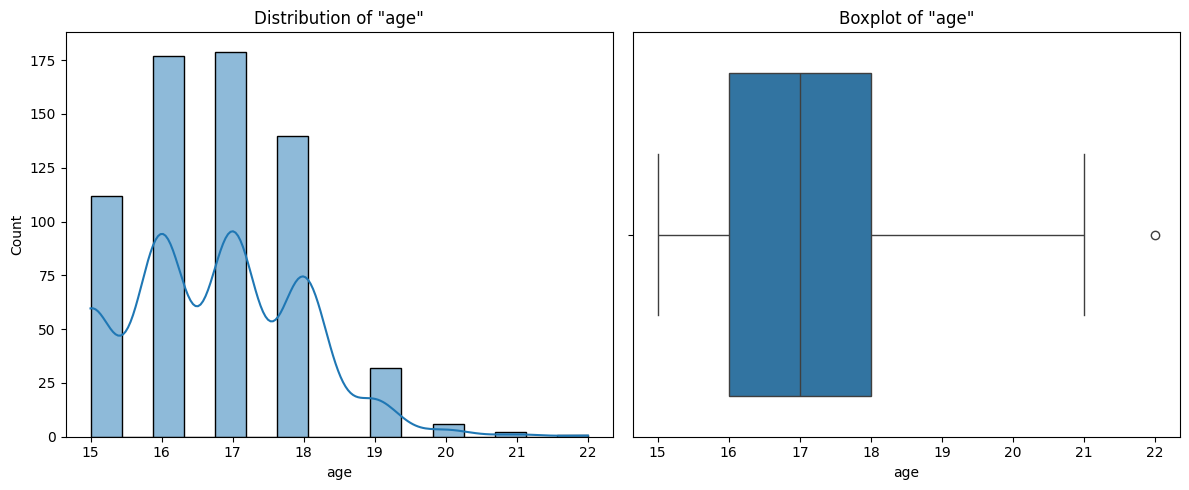

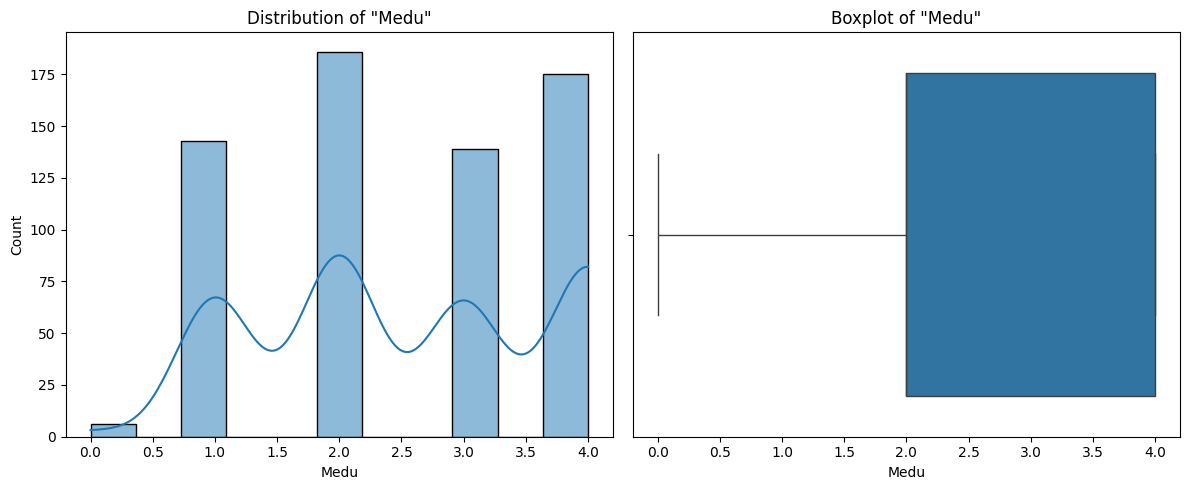

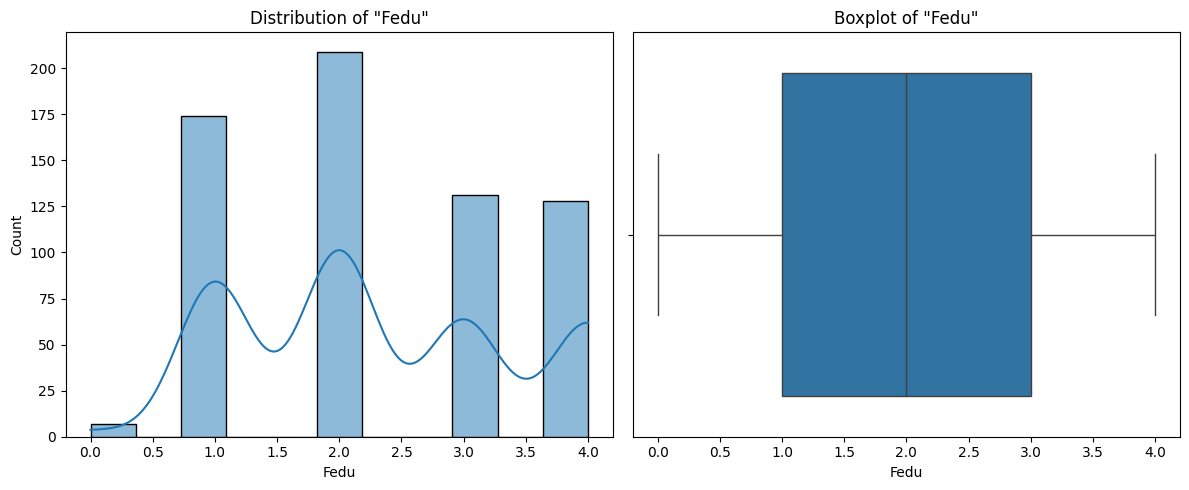

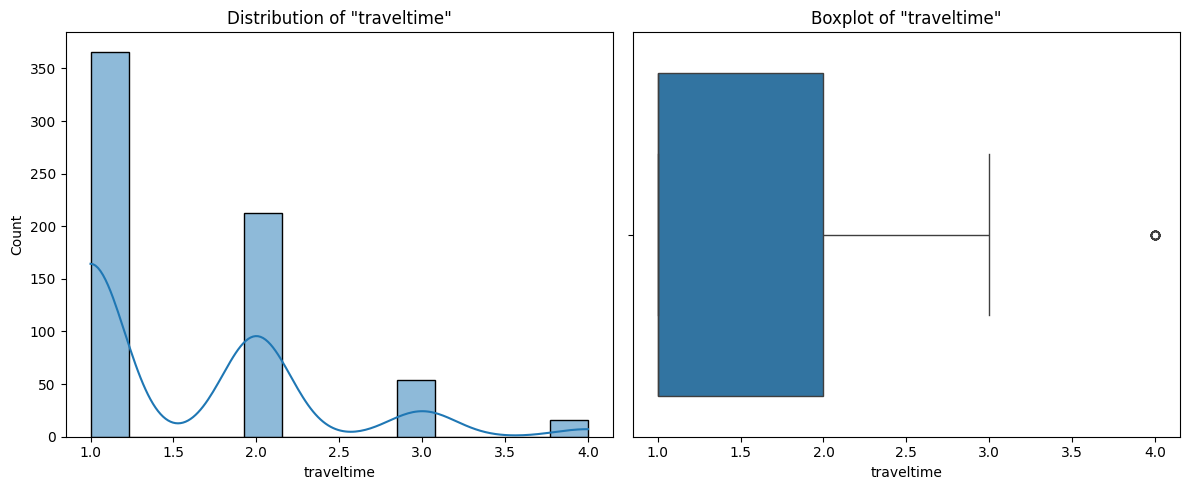

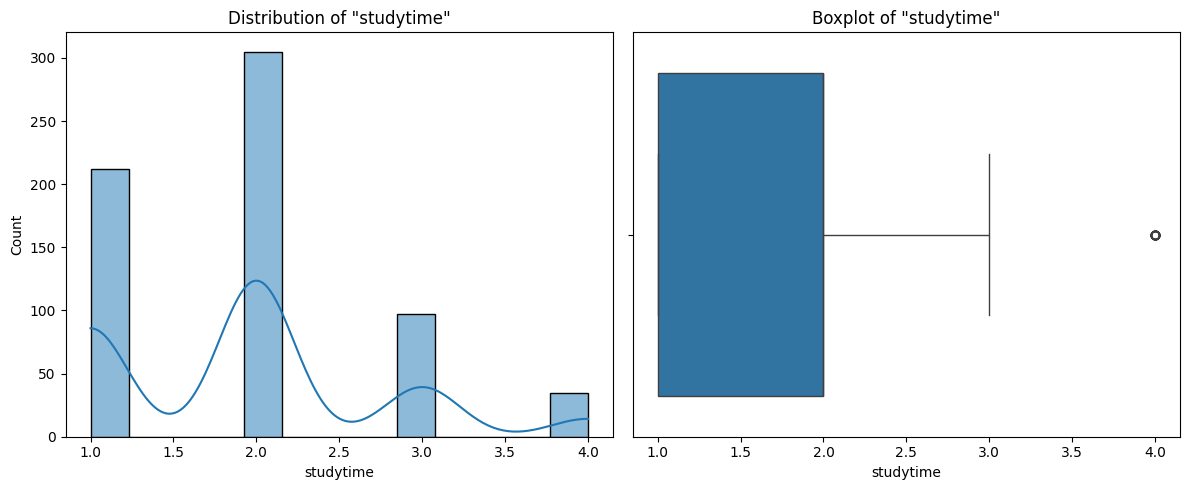

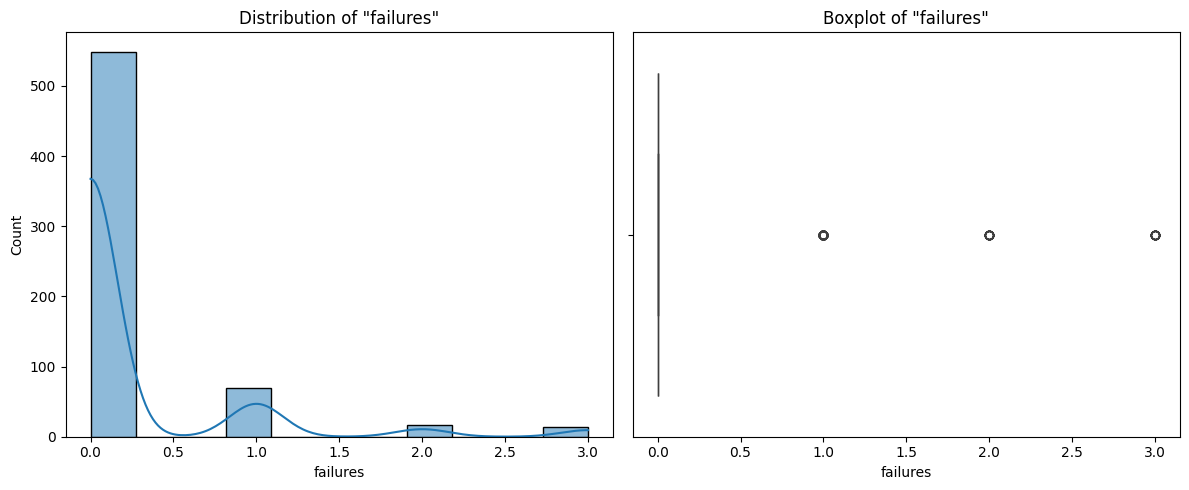

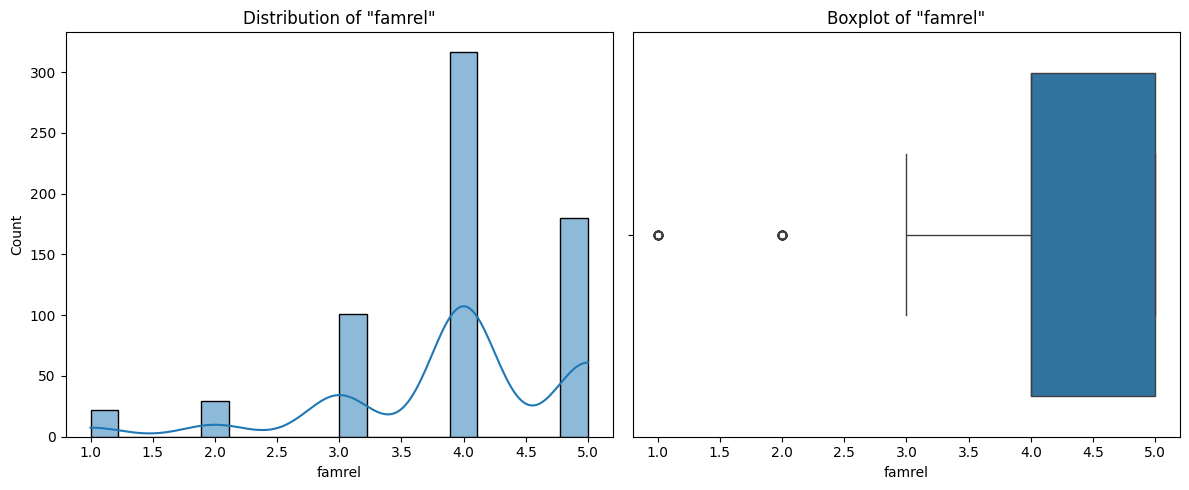

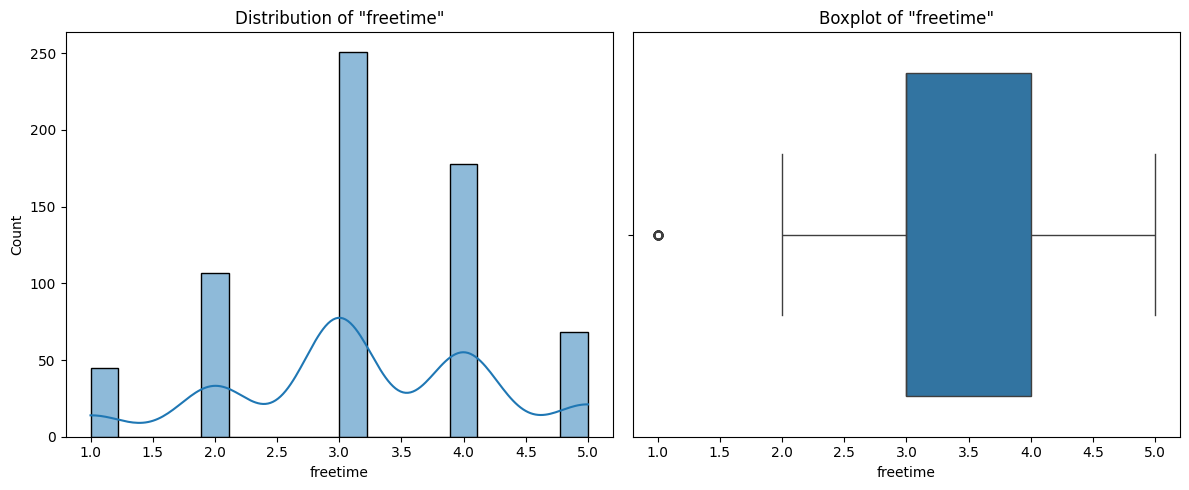

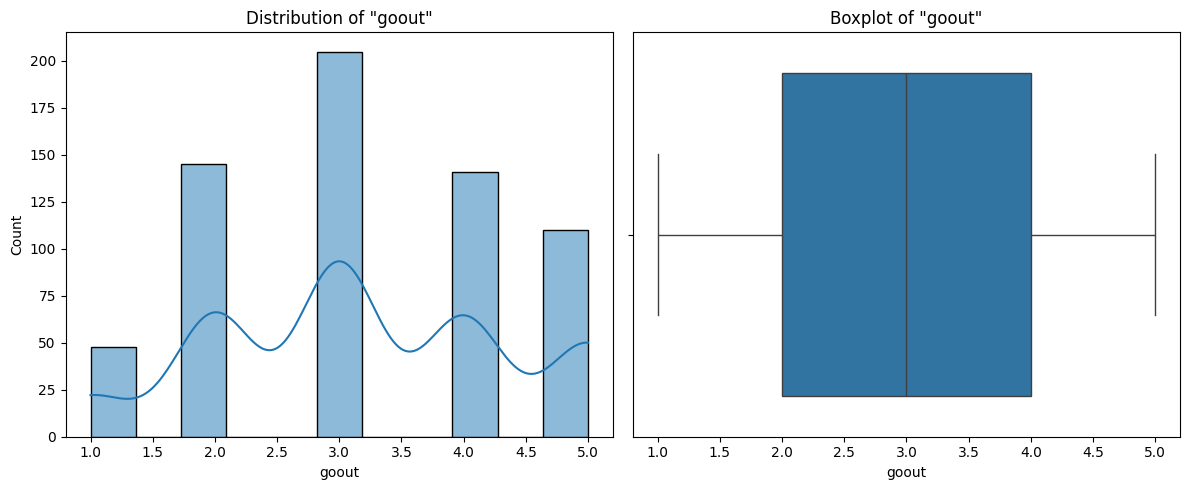

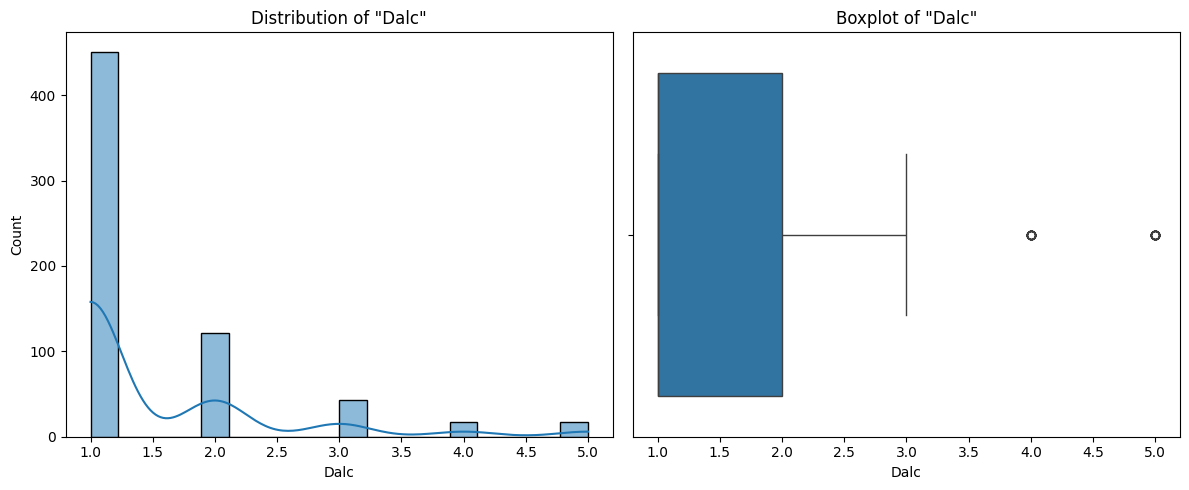

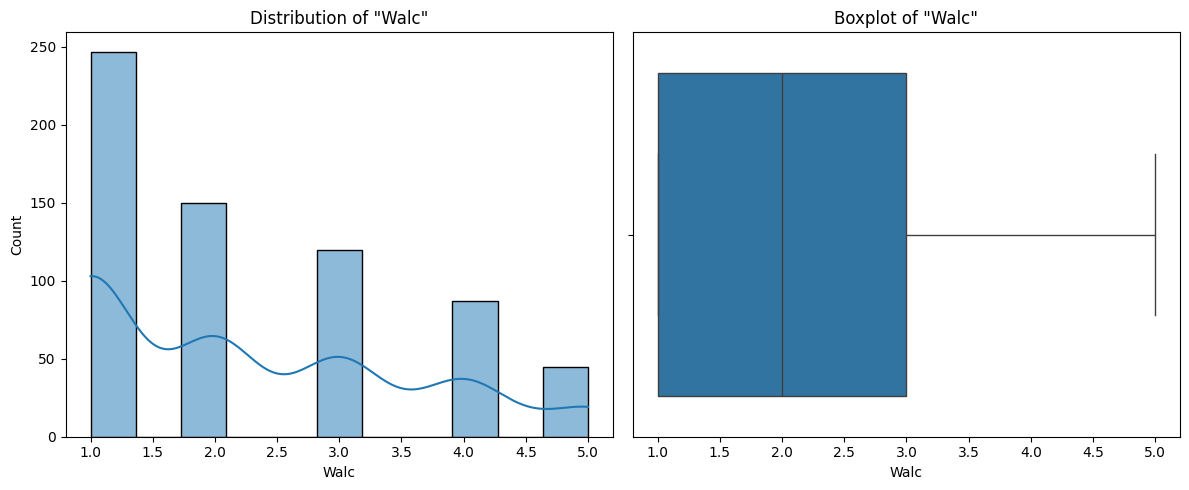

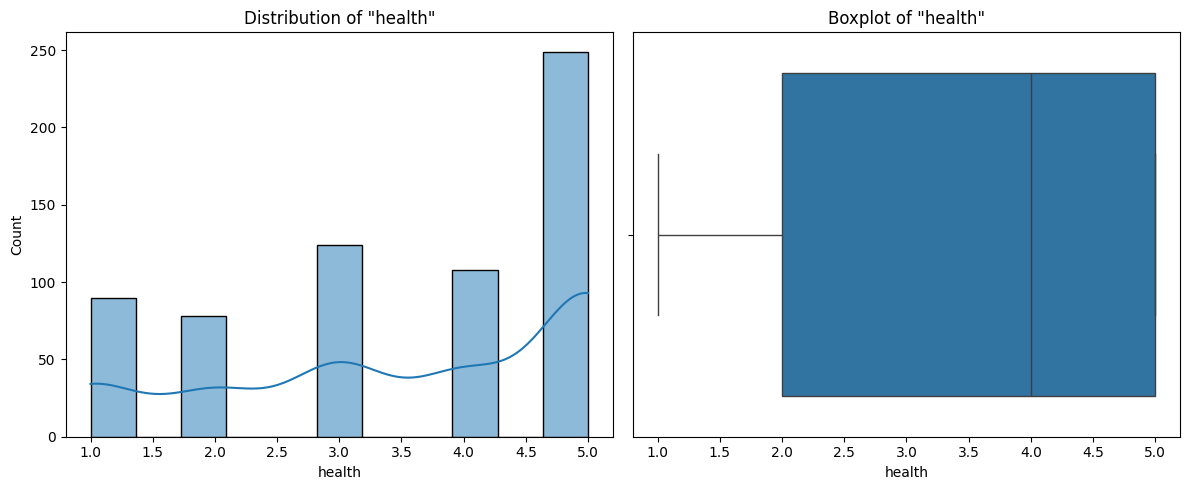

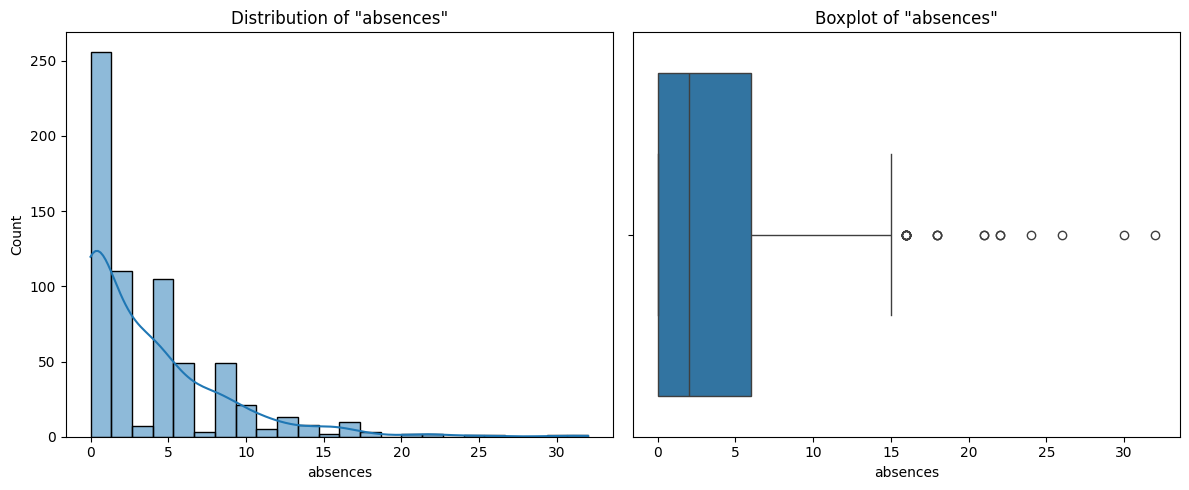

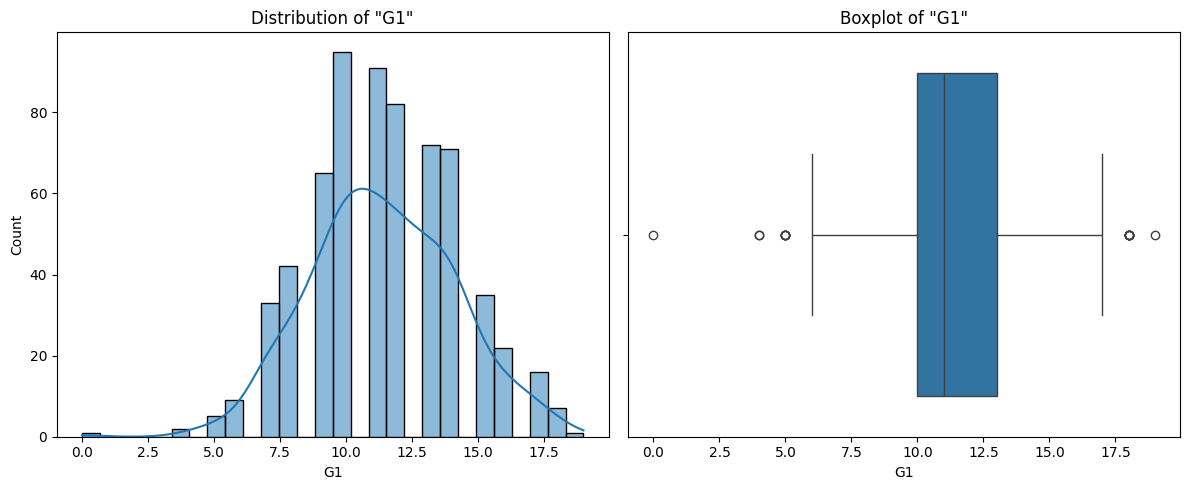

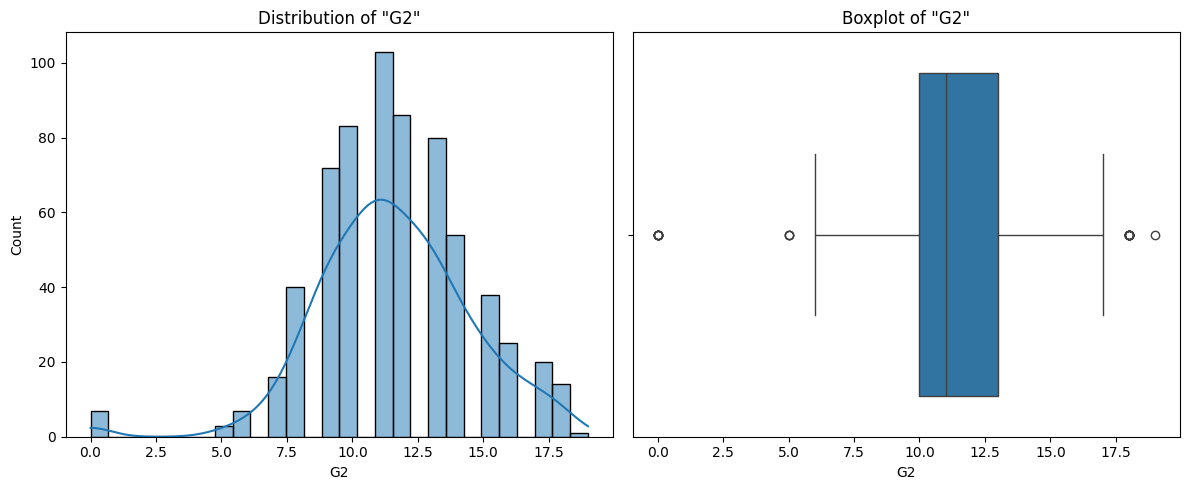

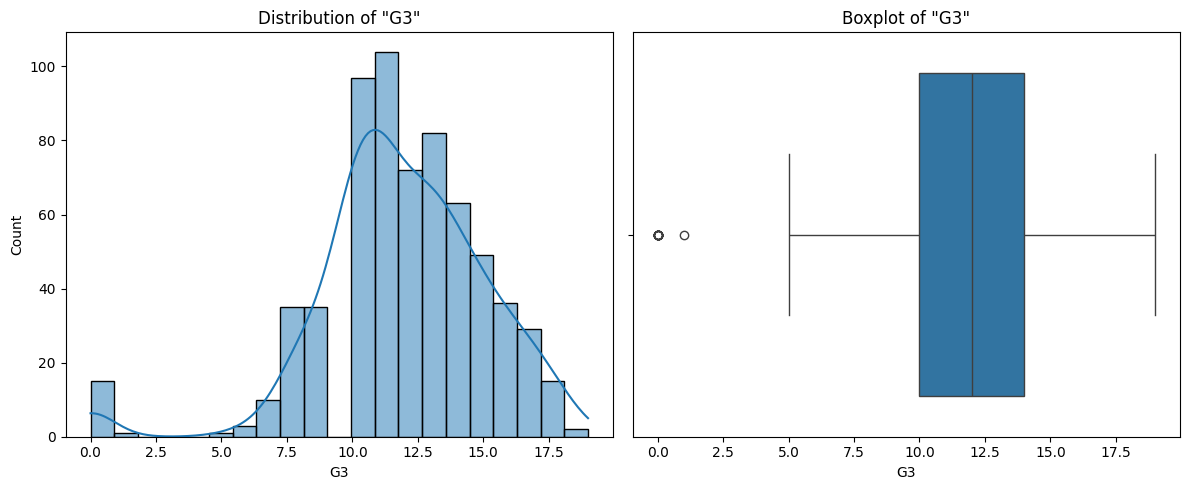

In [8]:
# creating histograms for numerical features
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # histogram for each numerical feature
    sns.histplot(studentperf_df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of "{col}"')

    # box plot for each numerical feature
    sns.boxplot(x=studentperf_df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of "{col}"')

    plt.tight_layout()
    plt.show()

By plotting the distributions of all columns, it can be seen that some values of the columns dominate the others (especially the feature columns). As for the grades (`G1` to `G3`), the distributions look approximately normal.

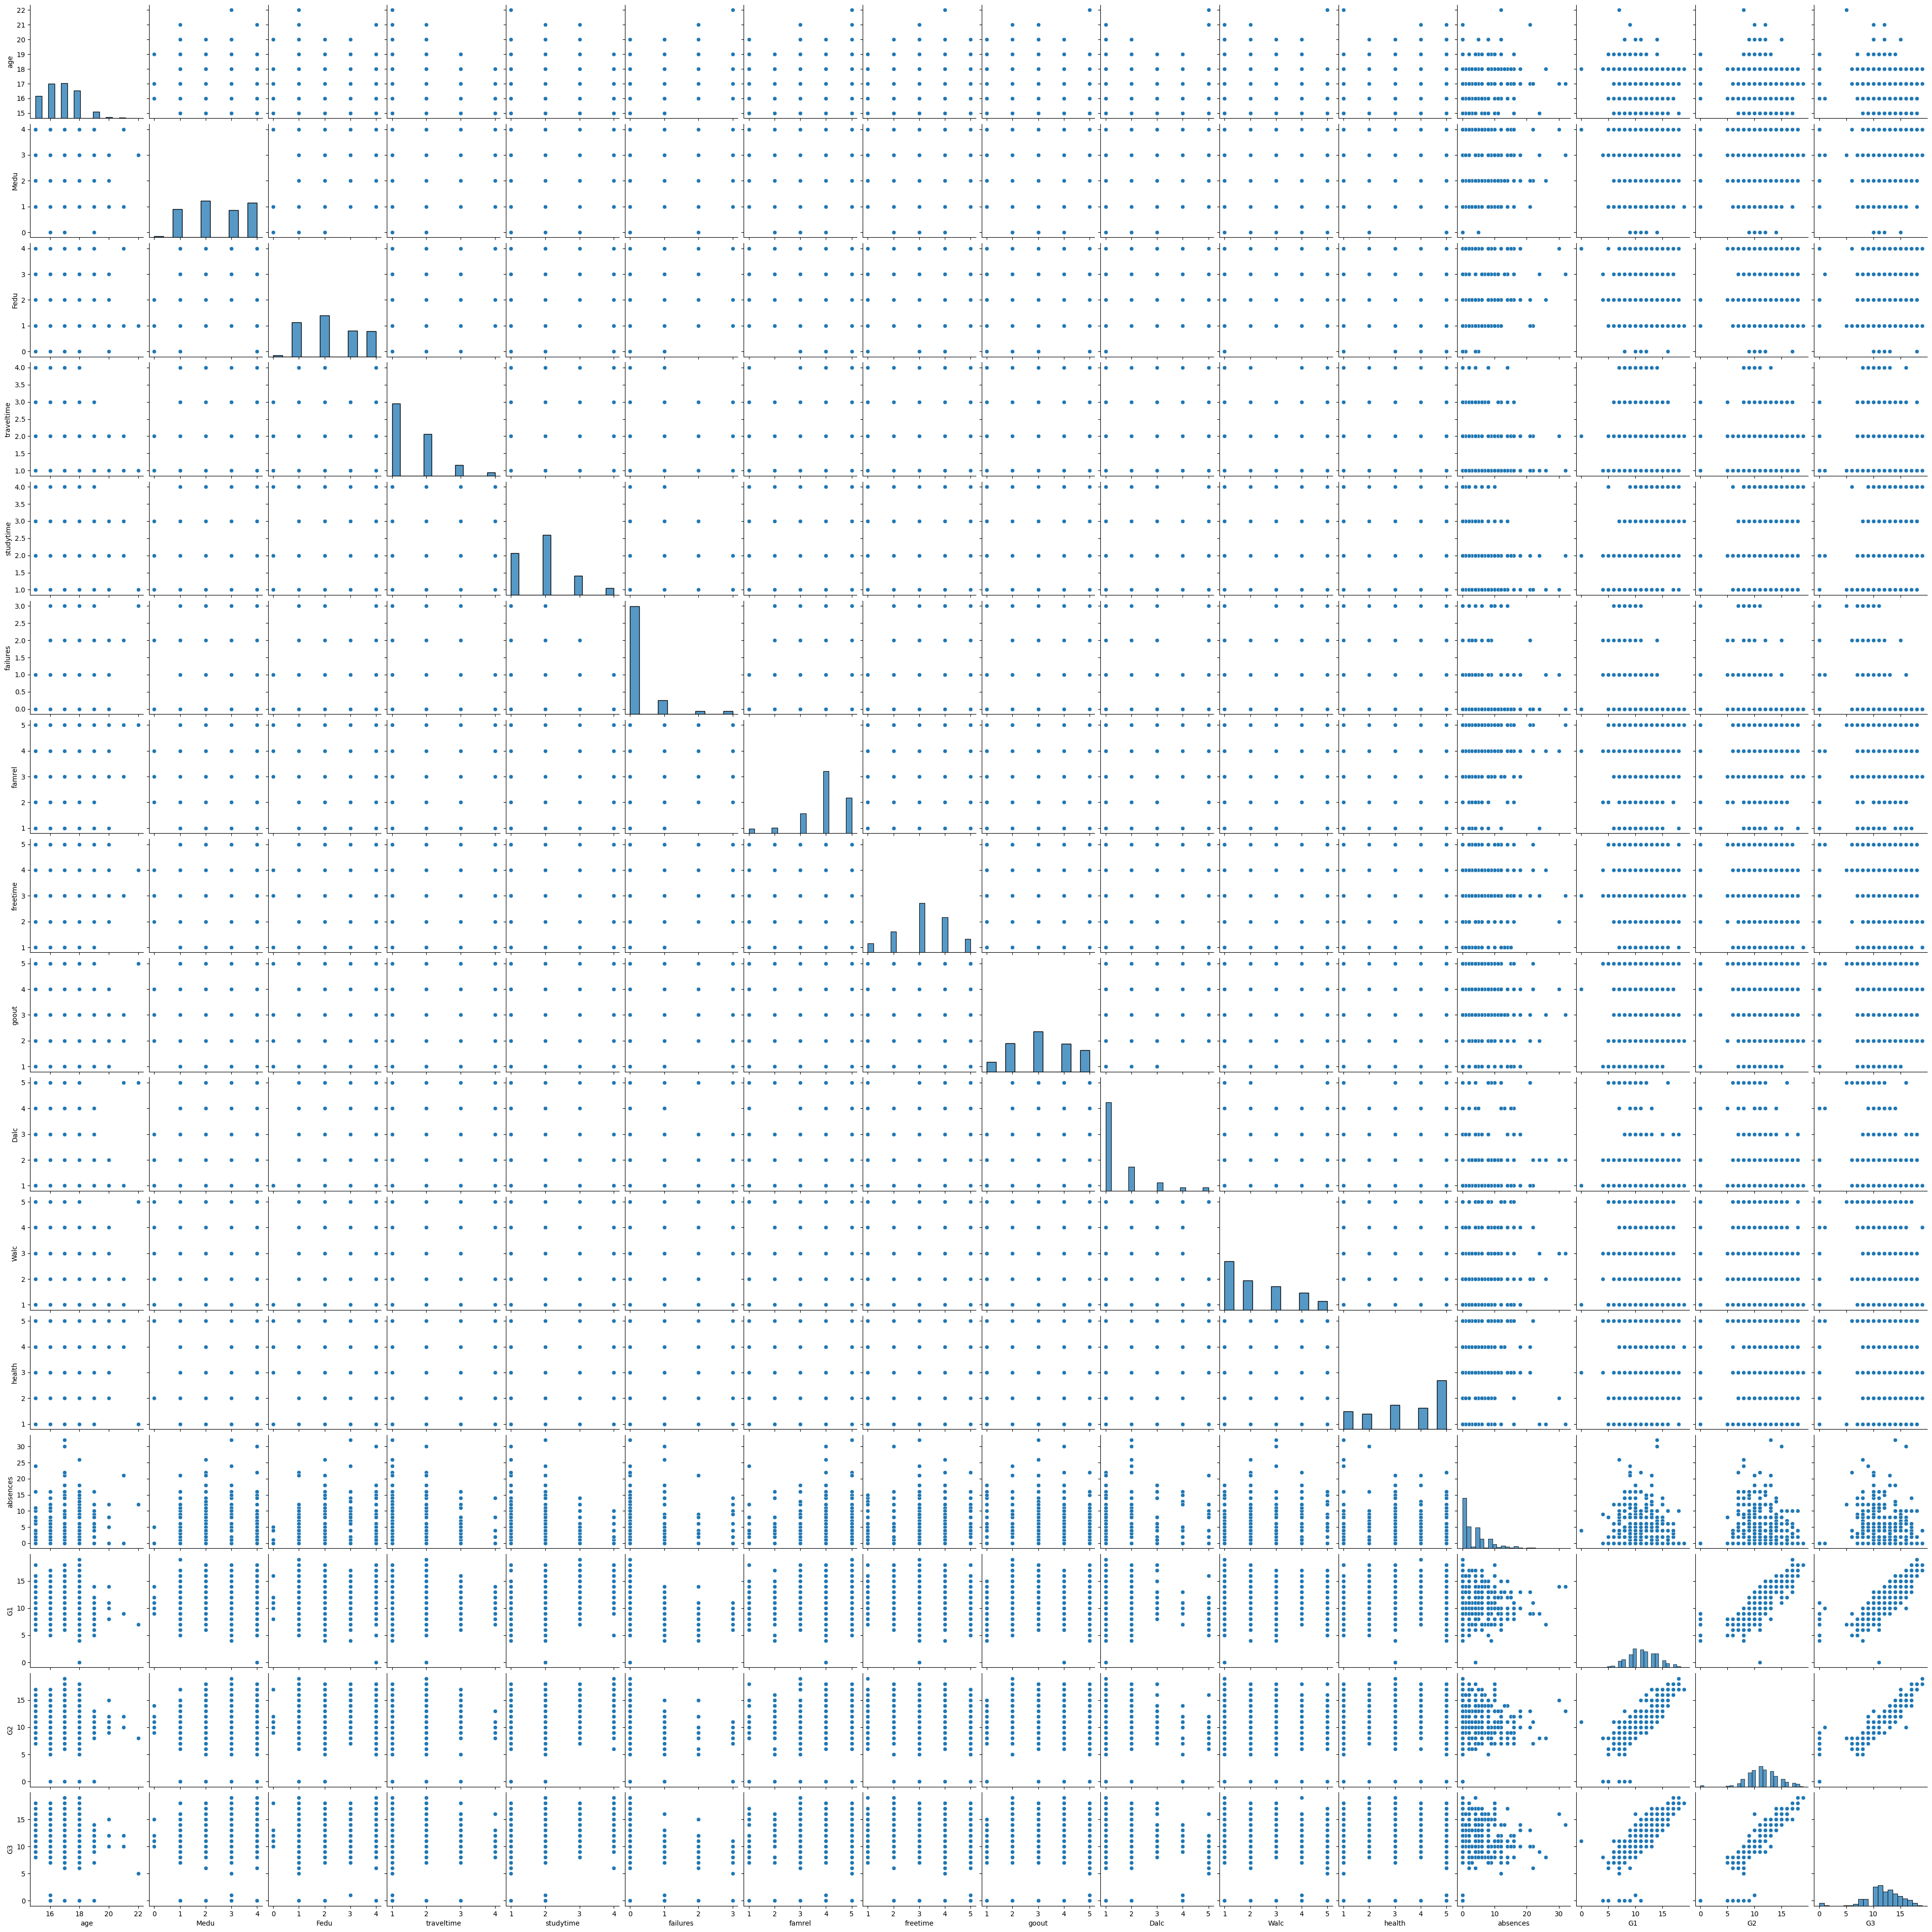

In [9]:
sns.pairplot(studentperf_df[numerical_cols])
plt.show()

It can be shown in the pairplot, specifically at the bottom right, that the grades are highly correlated. As for the features, there is really no clear "correlation" among them.

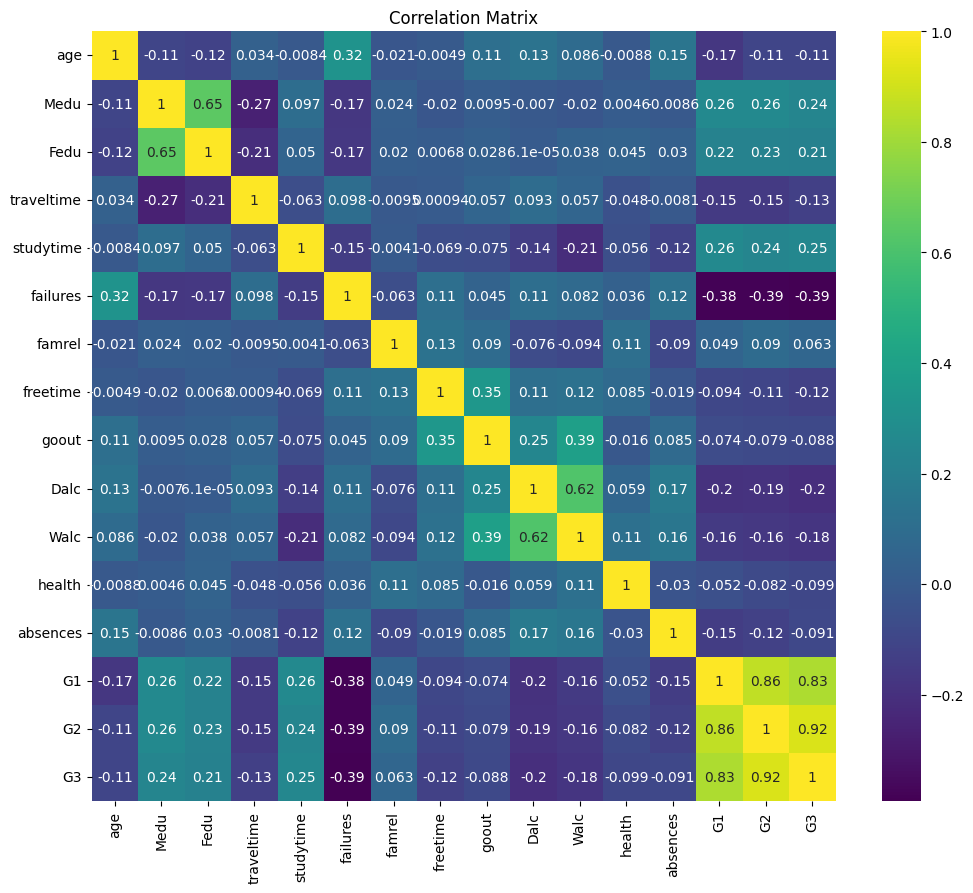

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(studentperf_df[numerical_cols].corr(), annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows the same information as that of the pairplot. Before, it has been that the grades are correlated - it shows in the correlation matrix that, indeed, they are. As for the features (majority at the left side of the matrix), it shows that there is really weak correlation among them.

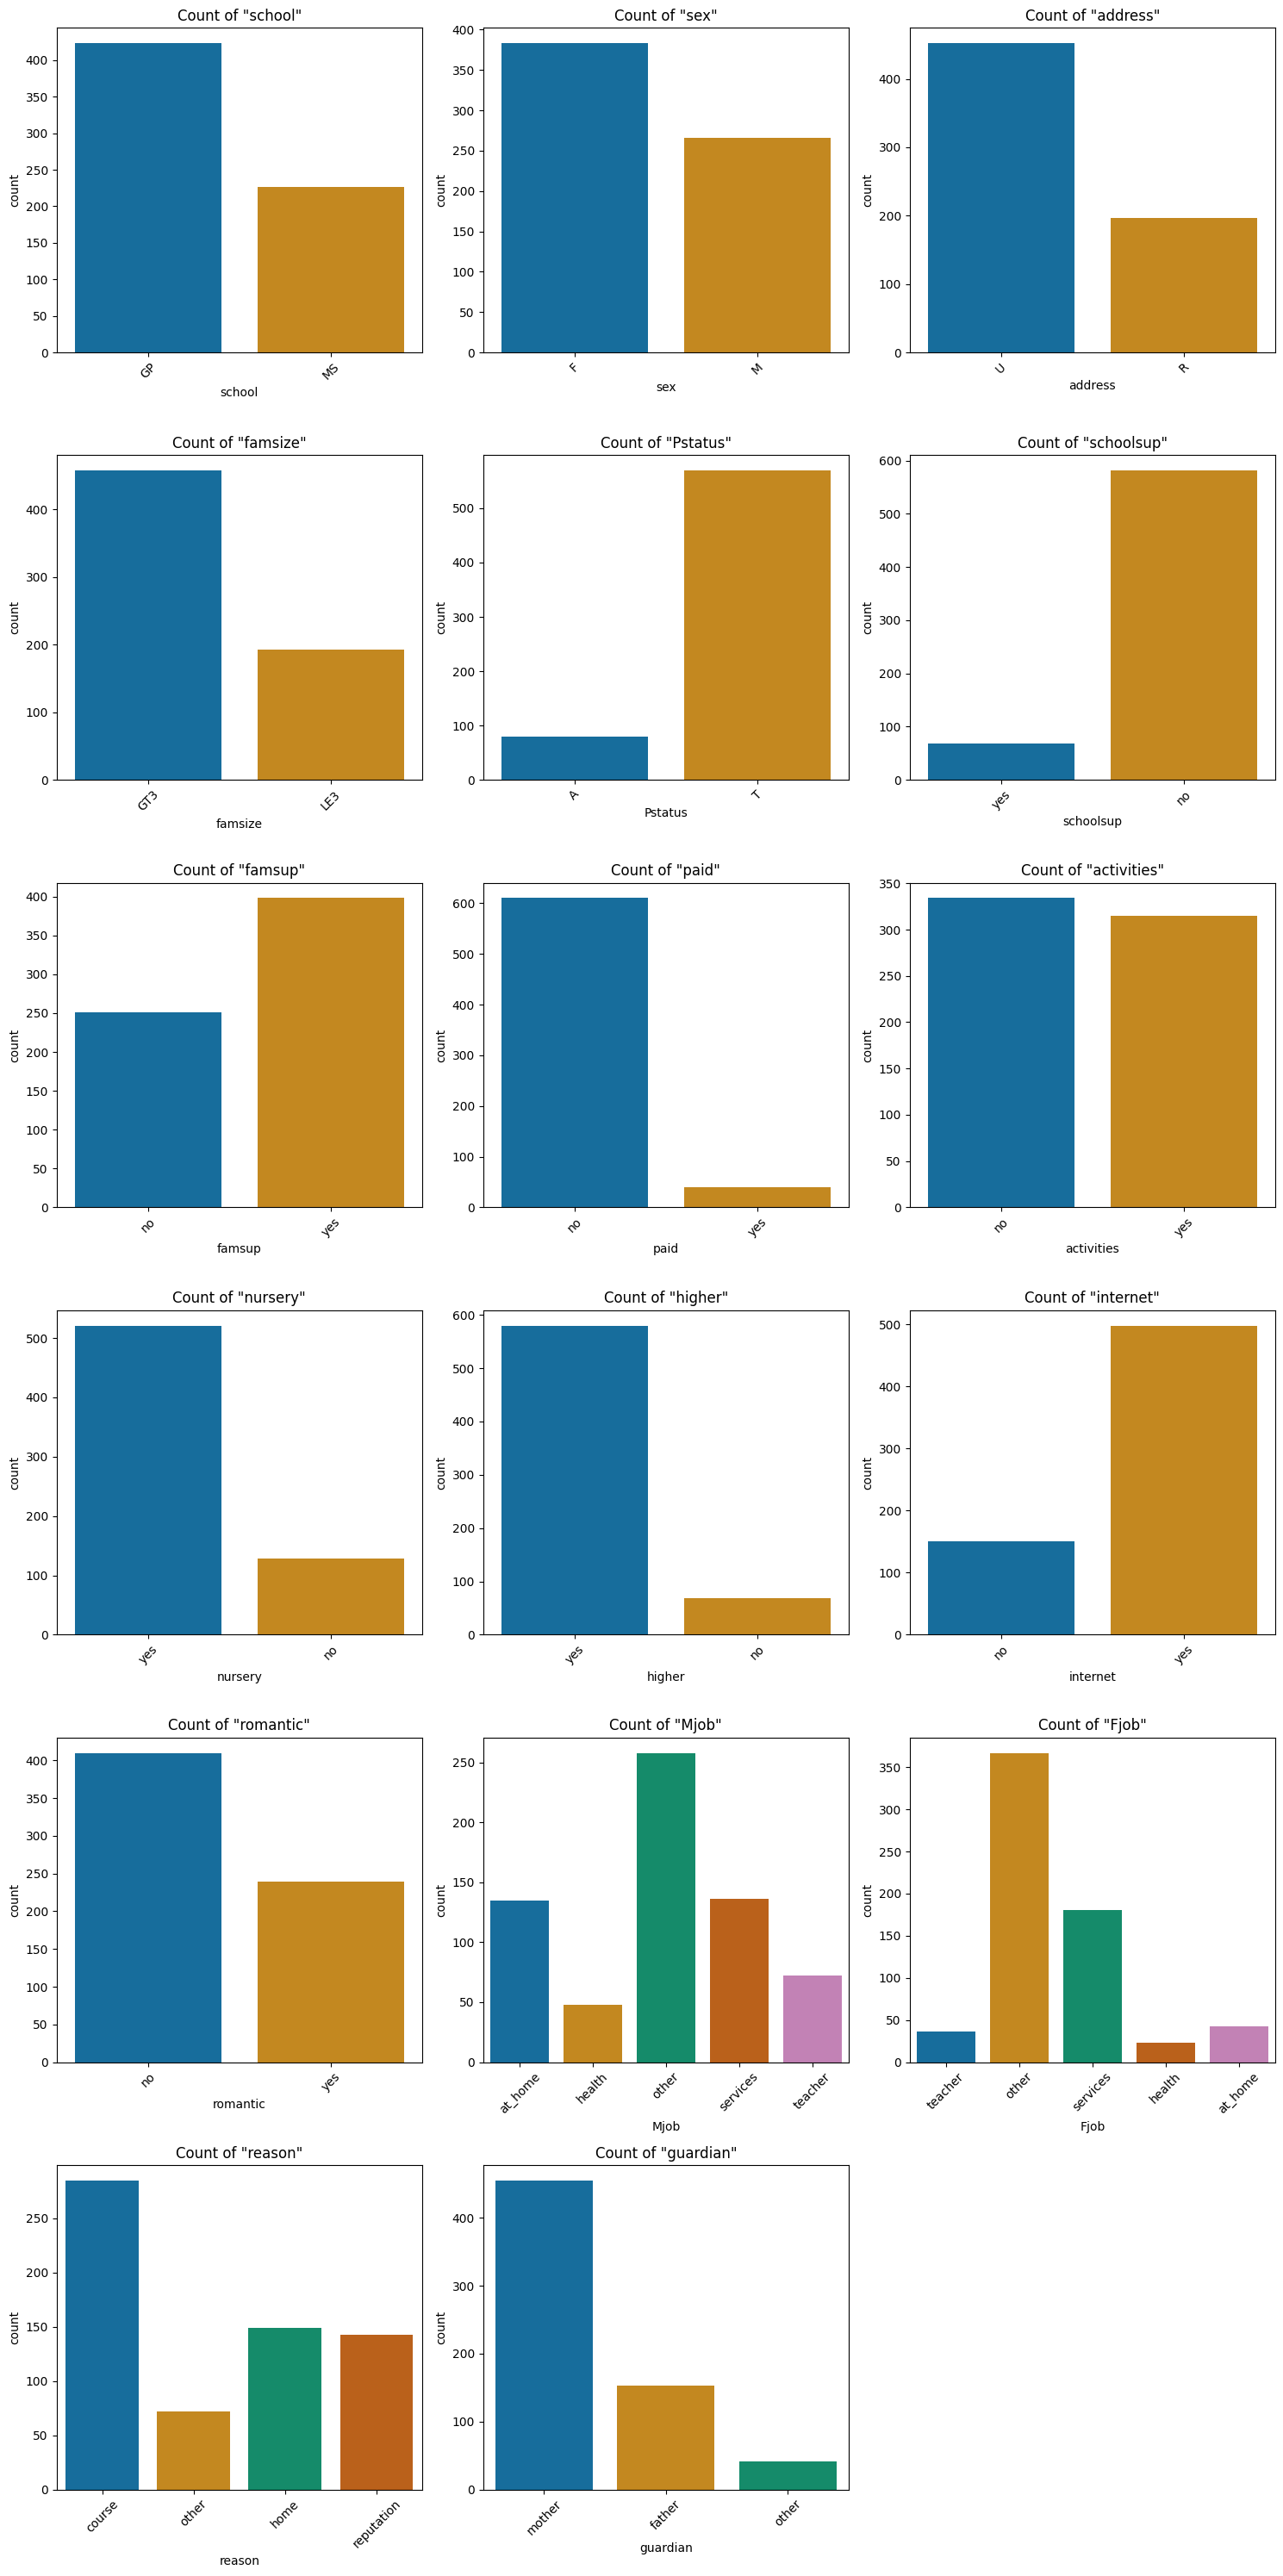

In [11]:
# separating binary and nominal columns for data transformation later
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

# list of original categorical columns (excluding numerical or ordinal)
original_categorical_cols = binary_cols + nominal_cols

# number of rows and columns for the subplots
num_cols = 3
num_rows = (len(original_categorical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

# creating count plots for each of the categorical columns
for i, col in enumerate(original_categorical_cols):
    sns.countplot(x=studentperf_df[col], ax=axes[i], hue=studentperf_df[col], palette="colorblind")
    axes[i].set_title(f'Count of "{col}"')
    axes[i].tick_params(axis='x', rotation=45) #rotate x-axis labels

# remove empty subplots (if any)
if len(original_categorical_cols) < num_rows * num_cols:
    for j in range(len(original_categorical_cols), num_rows * num_cols):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From the count plots, the binary features have clear imbalance between them. As for the other categorical features (`Mjob` to `guardian`), the plots show that there's one value dominating the feature.

## Data Transformation and Processing

One-Hot Encoding for the categorical features:

In [12]:
# doing one-hot encoding for binary features
studentperf_transformed_df = pd.get_dummies(studentperf_df, columns=binary_cols, drop_first=True)

# doing one-hot encoding for nominal features with multiple categories
studentperf_transformed_df = pd.get_dummies(studentperf_transformed_df, columns=nominal_cols, drop_first=True)

# Convert boolean columns to integers
for col in studentperf_transformed_df.columns:
    if studentperf_transformed_df[col].dtype == bool:
        studentperf_transformed_df[col] = studentperf_transformed_df[col].astype(int)

In [13]:
# checking the data types and column names again
studentperf_transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                649 non-null    int64
 1   Medu               649 non-null    int64
 2   Fedu               649 non-null    int64
 3   traveltime         649 non-null    int64
 4   studytime          649 non-null    int64
 5   failures           649 non-null    int64
 6   famrel             649 non-null    int64
 7   freetime           649 non-null    int64
 8   goout              649 non-null    int64
 9   Dalc               649 non-null    int64
 10  Walc               649 non-null    int64
 11  health             649 non-null    int64
 12  absences           649 non-null    int64
 13  G1                 649 non-null    int64
 14  G2                 649 non-null    int64
 15  G3                 649 non-null    int64
 16  school_MS          649 non-null    int64
 17  sex_M           

In [14]:
# checking the first rows of the transformed DataFrame
# temporarily set the option to display all columns
with pd.option_context('display.max_columns', None):
    # checking the data
    print(studentperf_transformed_df.head())

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  Walc  health  absences  G1  G2  G3  school_MS  sex_M  address_U  \
0     1     1       3         4   0  11  11          0      0          1   
1     1     1       3         2   9  11  11          0      0          1   
2     2     3       3         6  12  13  12          0      0          1   
3     1     1       5         0  14  14  14          0      0          1   
4     1     2       5         0  11  13  13          0      0          1   

   famsize_LE3  Pstatus_T  schoolsup_yes  famsup_yes  paid_yes

PCA for all features:

In [15]:
# standardizing the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(studentperf_transformed_df.drop(["G1", "G2", "G3"], axis=1))

# checking the first row of the scaled features
print(scaled_features[0])

[ 1.03169516  1.31021563  1.54071544  0.57671799  0.08365295 -0.37430512
  0.07260615 -0.17164654  0.69378496 -0.54355533 -0.99769466 -0.3710422
  0.07343336 -0.73094388 -0.83337685  0.66018233 -0.64817536 -2.66692707
  2.92303227 -1.25922888 -0.25285258 -0.97114045  0.49566257  0.34491378
 -1.81604329 -0.76349645 -0.2826073  -0.81230939 -0.51488563 -0.35324689
 -0.19167998 -1.14079728 -0.62189399  4.1264728  -0.54589376 -0.35324689
 -0.53160953  0.65297291 -0.25968098]


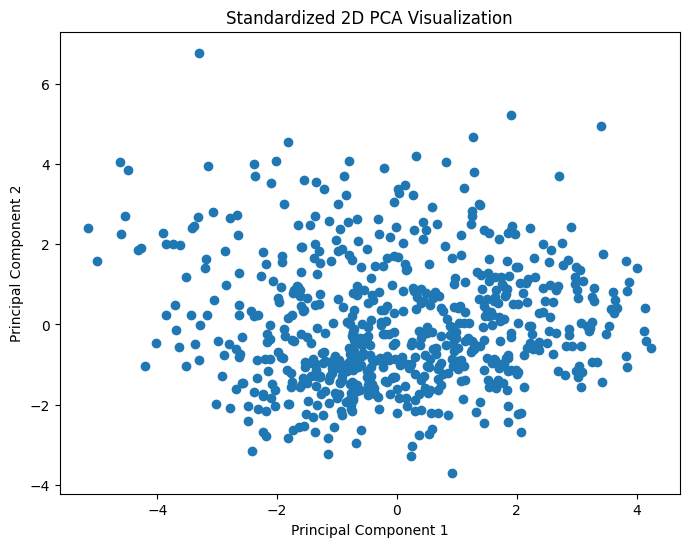

In [16]:
# performing 2D PCA
pca_2d = PCA(n_components=2)  # reduce to 2 dimensions
pca_2d_result = pca_2d.fit_transform(scaled_features)

# visualizing 2D PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1])
plt.title('Standardized 2D PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Clustering

               Algorithm  Silhouette Score
  Agglomerative (single)          0.576278
 Agglomerative (average)          0.517778
                  DBSCAN          0.493878
                 K-Means          0.403881
                     GMM          0.399013
     Spectral Clustering          0.381248
Agglomerative (complete)          0.365644
    Agglomerative (ward)          0.355390


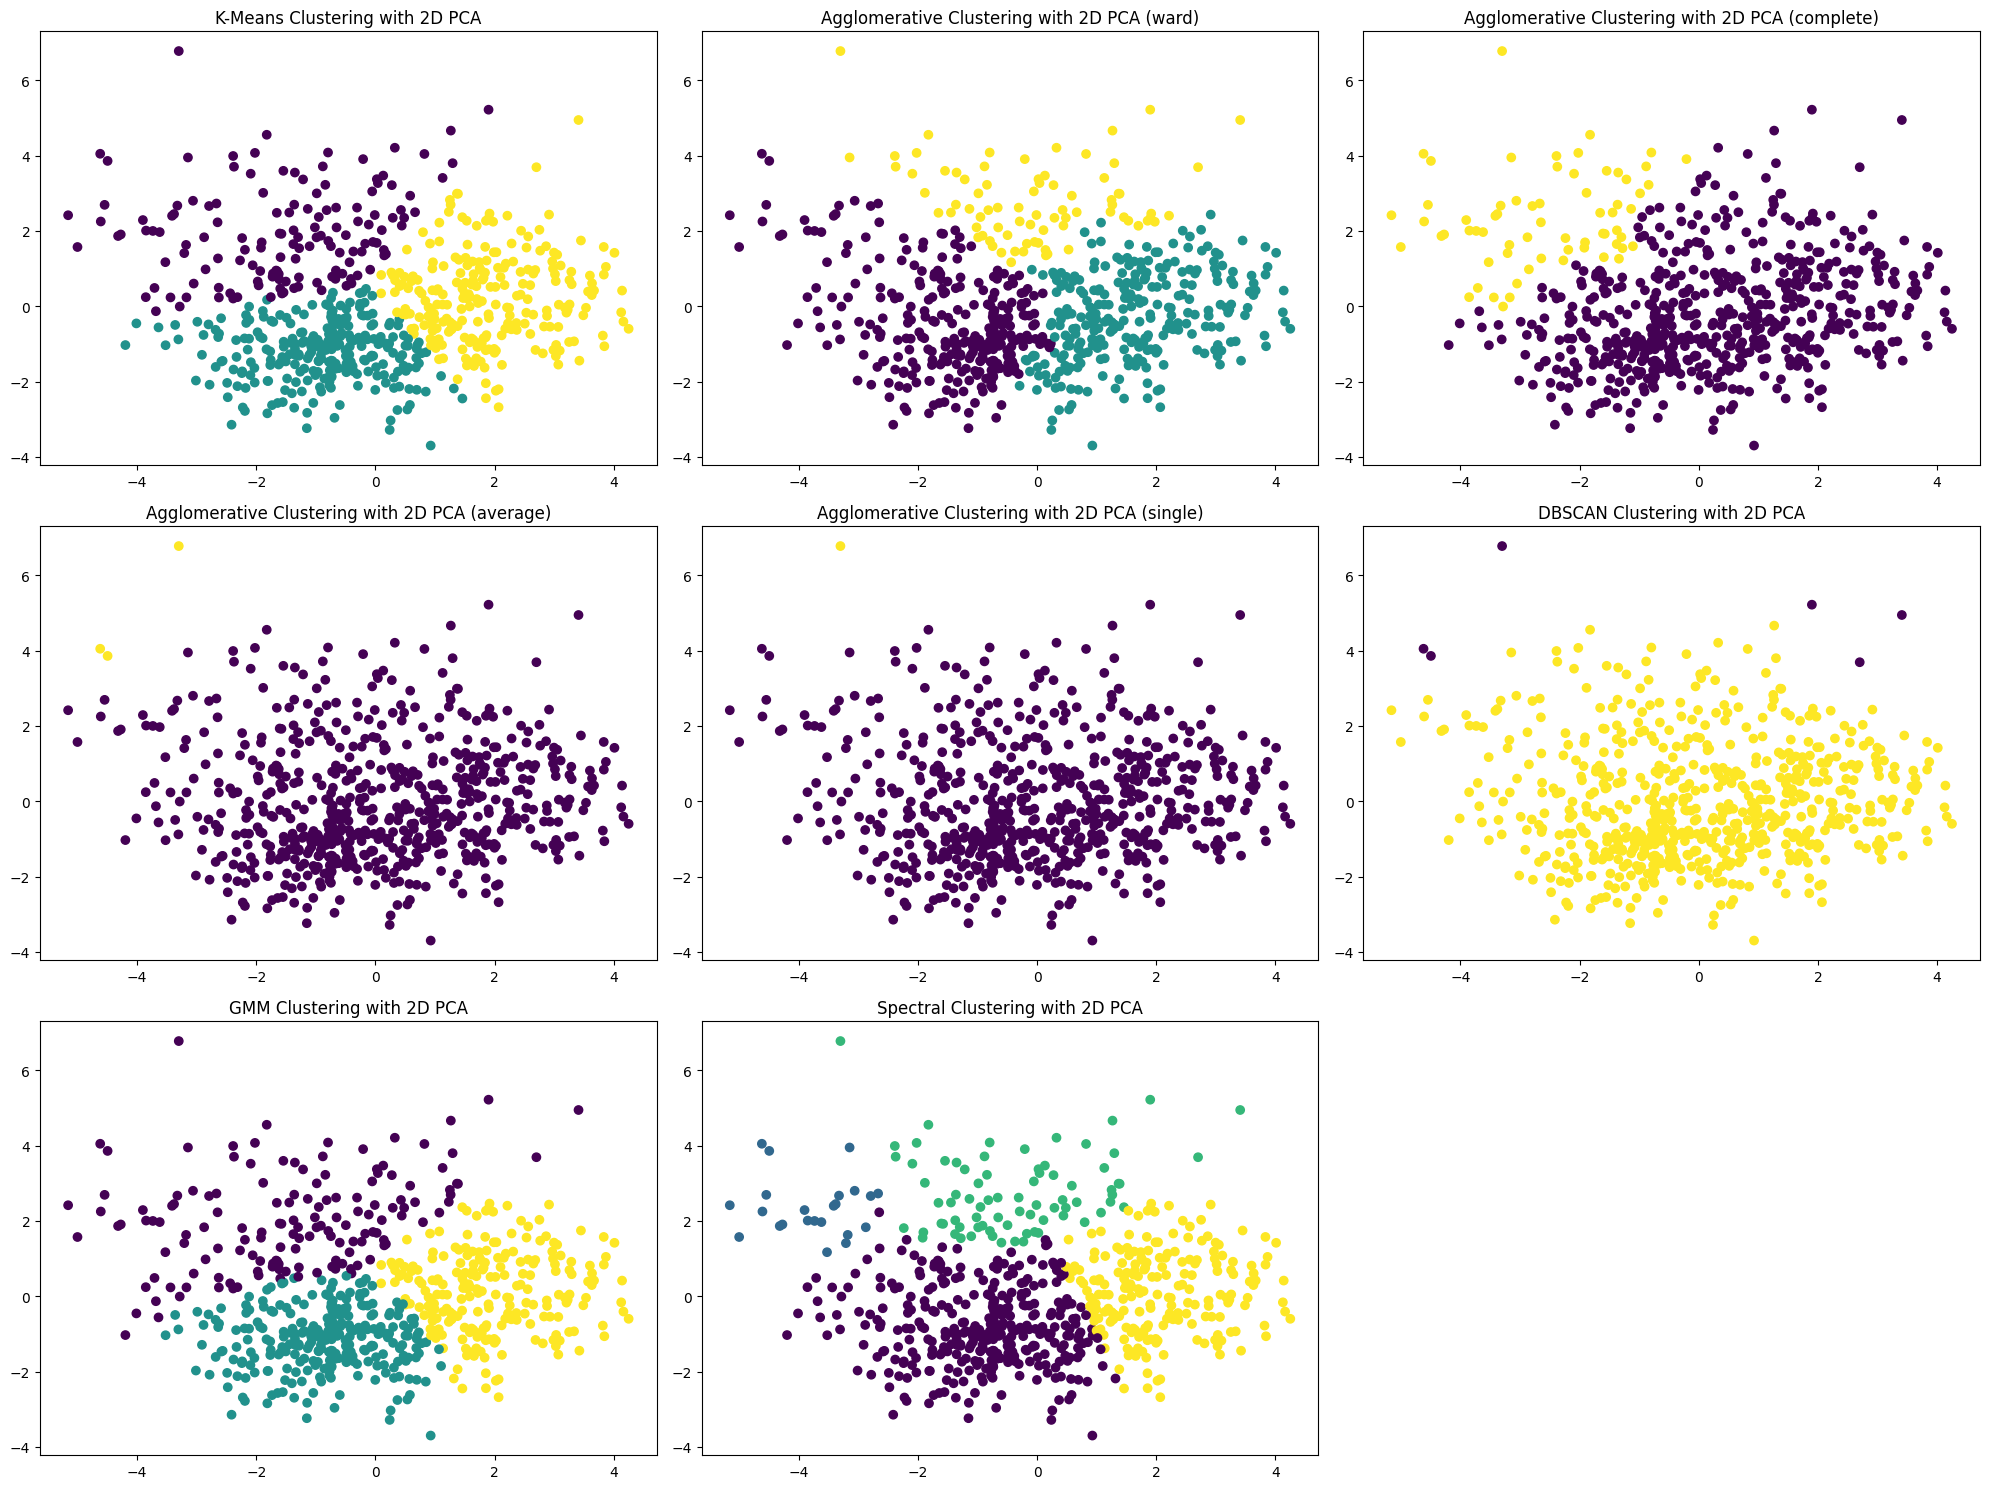

In [17]:
# hyperparameter search + clustering using 2D PCA data

# K-Means
kmeans_scores = []
k_range = range(2, 6)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=6)
    kmeans_clusters = kmeans.fit_predict(pca_2d_result)
    kmeans_scores.append(silhouette_score(pca_2d_result, kmeans_clusters))

best_k = k_range[np.argmax(kmeans_scores)]
kmeans = KMeans(n_clusters=best_k, random_state=6)
kmeans_clusters = kmeans.fit_predict(pca_2d_result)
studentperf_df['KMeans_Cluster'] = kmeans_clusters # add clusters to the original DataFrame for later analysis

# ====================

# Agglomerative Clustering (Linkage Methods)
linkage_methods = ['ward', 'complete', 'average', 'single']
best_agg_clusters = {}

for linkage in linkage_methods:
    agg_scores = []
    k_range = range(2, 6)
    for k in k_range:
        agg_clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        agg_clusters = agg_clustering.fit_predict(pca_2d_result)
        agg_scores.append(silhouette_score(pca_2d_result, agg_clusters))

    best_k_agg = k_range[np.argmax(agg_scores)]
    agg_clustering = AgglomerativeClustering(n_clusters=best_k_agg, linkage=linkage)
    best_agg_clusters[linkage] = agg_clustering.fit_predict(pca_2d_result)
    studentperf_df[f'Agg_{linkage}_Cluster'] = best_agg_clusters[linkage] # add clusters to the original DataFrame for later analysis

# ====================

# DBSCAN
dbscan_scores = []
eps_range = np.arange(0.1, 1.0, 0.1)

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    dbscan_clusters = dbscan.fit_predict(pca_2d_result)
    if len(np.unique(dbscan_clusters)) > 1:
        dbscan_scores.append(silhouette_score(pca_2d_result, dbscan_clusters))
    else:
        dbscan_scores.append(-1)

best_eps = eps_range[np.argmax(dbscan_scores)]
dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_clusters = dbscan.fit_predict(pca_2d_result)
studentperf_df['DBSCAN_Cluster'] = dbscan_clusters # add clusters to the original DataFrame for later analysis

# ====================

# GMM
gmm_scores = []
n_components_range = range(2, 6)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=6)
    gmm_clusters = gmm.fit_predict(pca_2d_result)
    gmm_scores.append(silhouette_score(pca_2d_result, gmm_clusters))

best_n_components = n_components_range[np.argmax(gmm_scores)]
gmm = GaussianMixture(n_components=best_n_components, random_state=6)
gmm_clusters = gmm.fit_predict(pca_2d_result)
studentperf_df['GMM_Cluster'] = gmm_clusters # add clusters to the original DataFrame for later analysis

# ====================

# Spectral Clustering
spectral_scores = []
k_range = range(2, 6)

for k in k_range:
    spectral = SpectralClustering(n_clusters=k, random_state=6)
    spectral_clusters = spectral.fit_predict(pca_2d_result)
    spectral_scores.append(silhouette_score(pca_2d_result, spectral_clusters))

best_k_spectral = k_range[np.argmax(spectral_scores)]
spectral = SpectralClustering(n_clusters=best_k_spectral, random_state=6)
spectral_clusters = spectral.fit_predict(pca_2d_result)
studentperf_df['Spectral_Cluster'] = spectral_clusters # add clusters to the original DataFrame for later analysis

# ====================

# evaluation
silhouette_results = {
    'Algorithm': ['K-Means'] + [f'Agglomerative ({linkage})' for linkage in linkage_methods] + ['DBSCAN', 'GMM', 'Spectral Clustering'],
    'Silhouette Score': [silhouette_score(pca_2d_result, kmeans_clusters)] + [silhouette_score(pca_2d_result, best_agg_clusters[linkage]) for linkage in linkage_methods] + [silhouette_score(pca_2d_result, dbscan_clusters), silhouette_score(pca_2d_result, gmm_clusters), silhouette_score(pca_2d_result, spectral_clusters)]
}

silhouette_df = pd.DataFrame(silhouette_results).sort_values(by='Silhouette Score', ascending=False)
print(silhouette_df.to_string(index=False)) # print the DataFrame without the index

# plotting clusters in 2D
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

axes[0].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=kmeans_clusters, cmap='viridis')
axes[0].set_title('K-Means Clustering with 2D PCA')

for i, linkage in enumerate(linkage_methods):
    axes[i+1].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=best_agg_clusters[linkage], cmap='viridis')
    axes[i+1].set_title(f'Agglomerative Clustering with 2D PCA ({linkage})')

axes[5].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=dbscan_clusters, cmap='viridis')
axes[5].set_title('DBSCAN Clustering with 2D PCA')

axes[6].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=gmm_clusters, cmap='viridis')
axes[6].set_title('GMM Clustering with 2D PCA')

axes[7].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=spectral_clusters, cmap='viridis')
axes[7].set_title('Spectral Clustering with 2D PCA')

fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

By testing different clustering methods, silhouette scores are obtained and the predicted clusters are plotted along with the PCA-transformed data. From the silhouette scores, it shows that the method achieving the highest score is that of Agglomerative Clustering using 'single' as the linkage method. However, when the scatter plot is looked at, it shows that the result is a bit trivial: one big chunk of points is considered as a cluster while a single outlier (far from the chunk of points) is considered as another cluster. Mathematically, this results to, definitely, a high silhouette score. The same can be said of the results obtained using another Agglomerative Clustering method (using 'average' as the linkage method) and DBSCAN. Disregarding these clustering methods with rather trivial results, it is interesting to analyze the results obtained from K-Means Clustering, Agglomerative Clustering using ward linkage, Agglomerative Clustering using complete linkage, GMM Clustering, and Spectral Clustering (the last five methods ranked according to silhouette score).

In [18]:
# checking the original DataFrame with the added cluster
with pd.option_context('display.max_columns', None):
    # checking the data
    print(studentperf_df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
1     GP   F   17       U     GT3       T     1     1  at_home     other   
2     GP   F   15       U     LE3       T     1     1  at_home     other   
3     GP   F   15       U     GT3       T     4     2   health  services   
4     GP   F   16       U     GT3       T     3     3    other     other   

   reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
0  course   mother           2          2         0       yes     no   no   
1  course   father           1          2         0        no    yes   no   
2   other   mother           1          2         0       yes     no   no   
3    home   mother           1          3         0        no    yes   no   
4    home   father           1          2         0        no    yes   no   

  activities nursery higher internet romantic  famrel  freetime  goout  Dalc  \


K-Means Clustering Analysis:

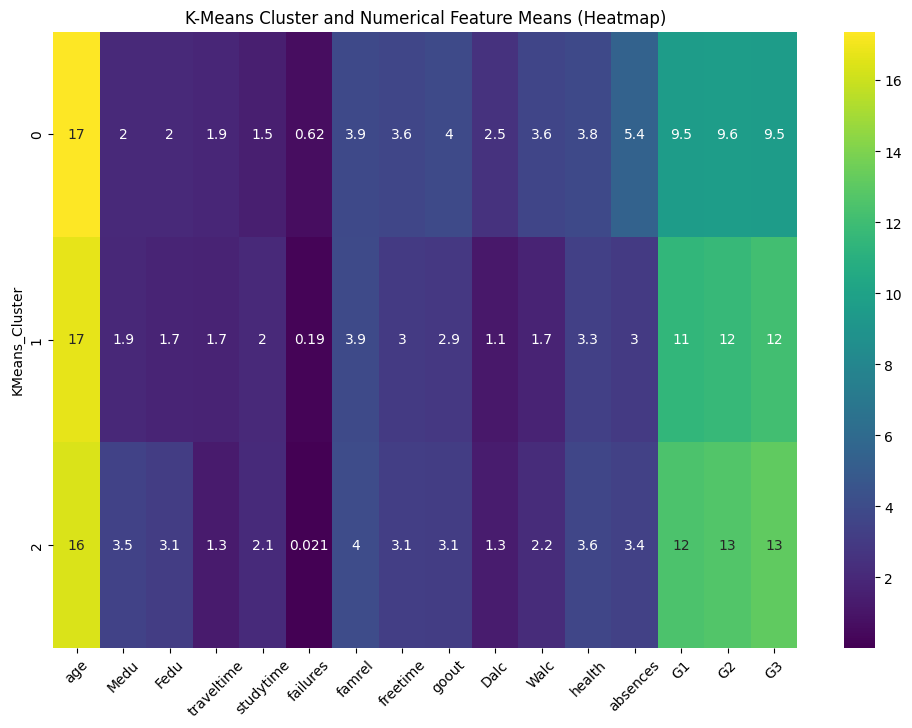

In [19]:
# creating a heatmap to analyze the clusters vis-a-vis the numerical columns
kmeans_cluster_means = studentperf_df.groupby('KMeans_Cluster')[numerical_cols].mean()
plt.figure(figsize=(12, 8))
sns.heatmap(kmeans_cluster_means, annot=True, cmap='viridis')
plt.title('K-Means Cluster and Numerical Feature Means (Heatmap)')
plt.xticks(rotation=45)
plt.show()

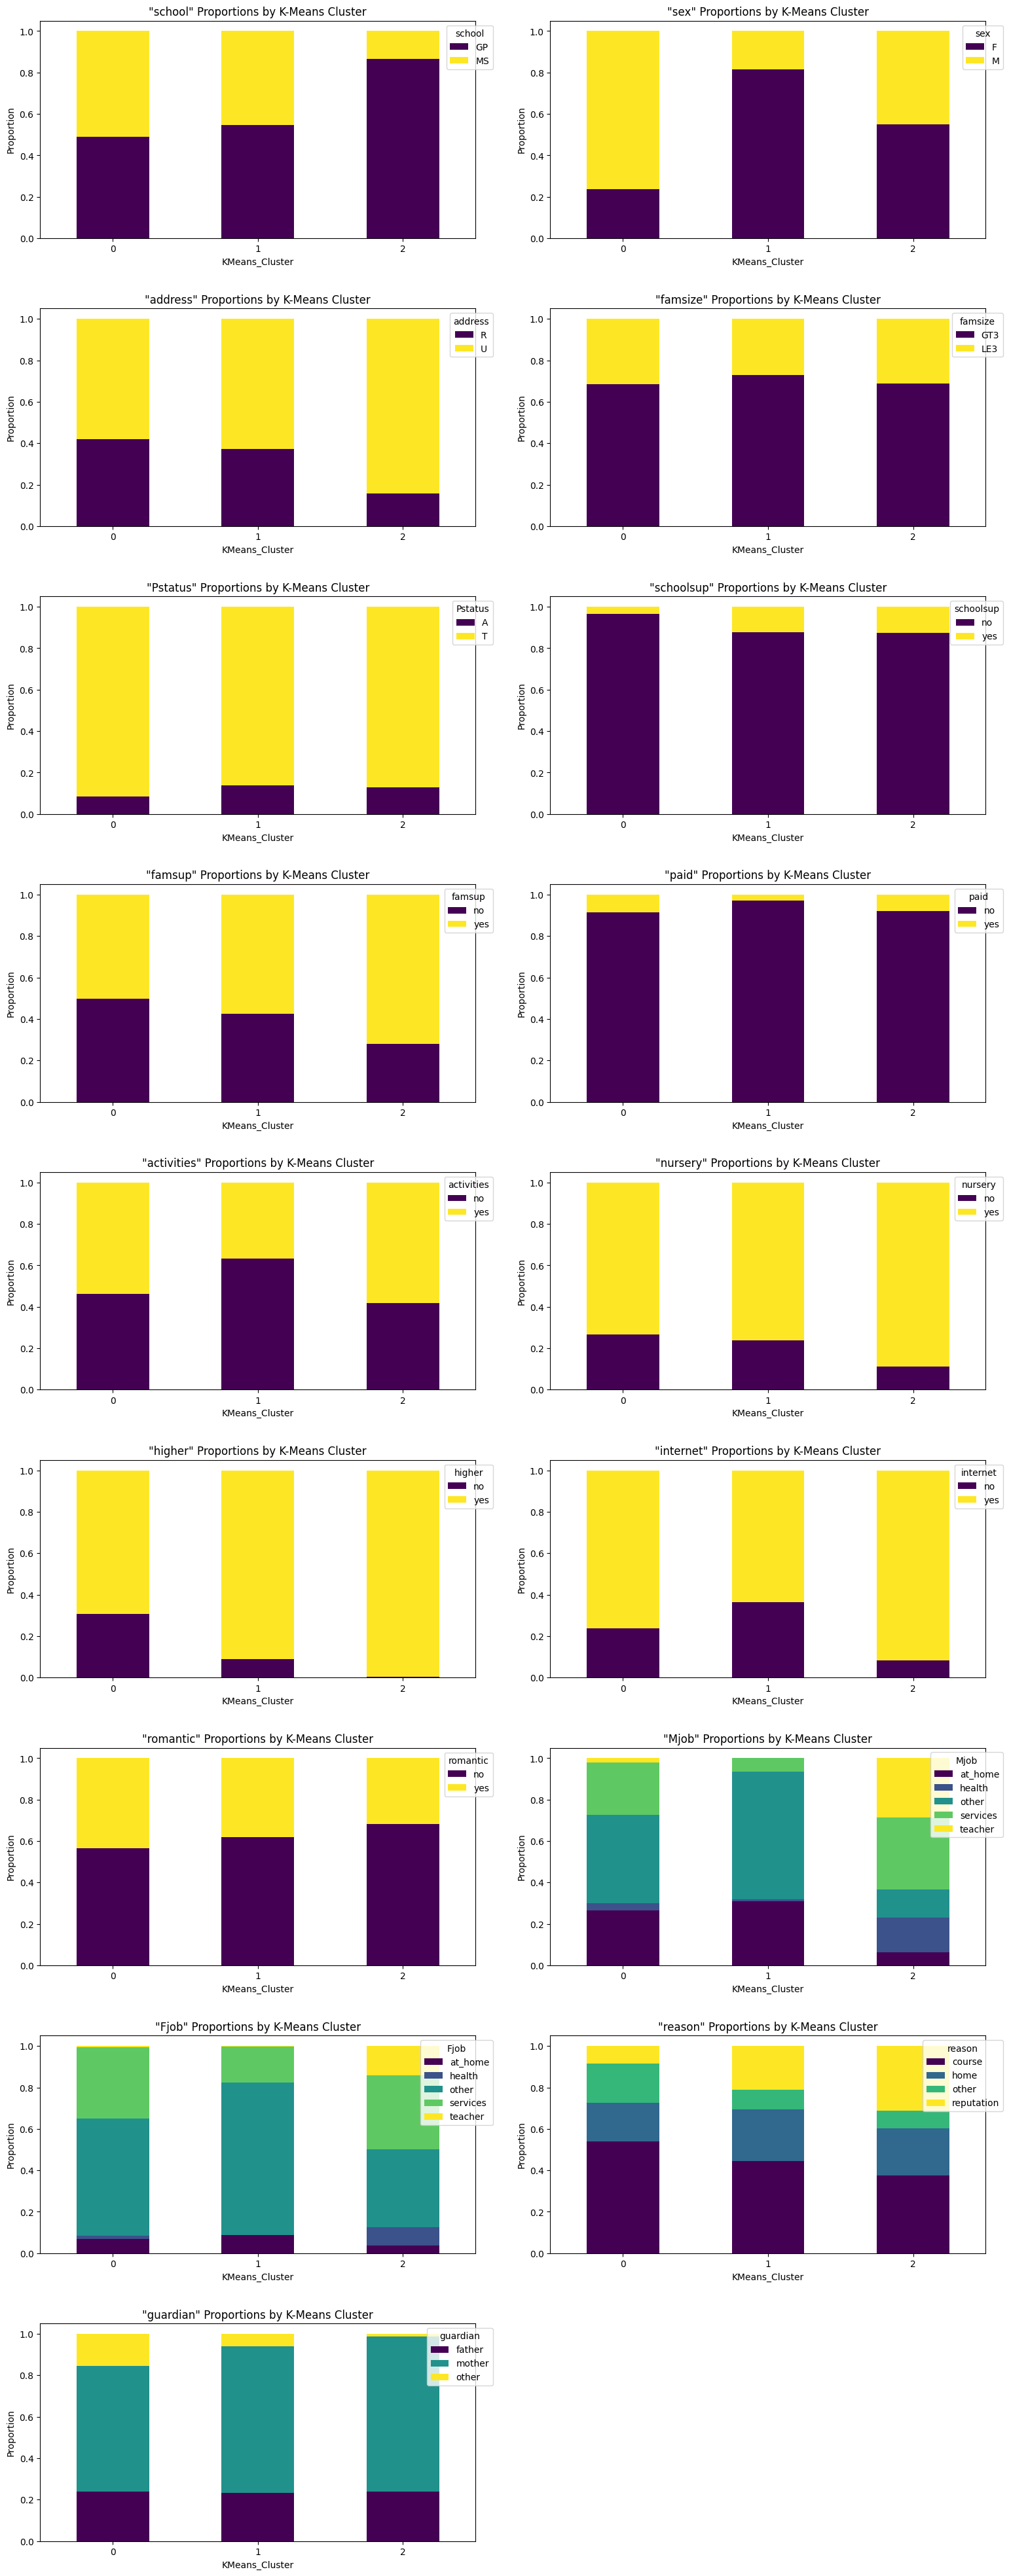

In [20]:
# selecting only the K-Means Cluster Column
cluster_col = 'KMeans_Cluster'

# creating subplots of stacked bar plots
n_rows = 9
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 40))
axes = axes.flatten()

# iterating through all categorical columns
for i, cat_col in enumerate(original_categorical_cols):
    cluster_cat = pd.crosstab(studentperf_df[cluster_col], studentperf_df[cat_col]) # creating crosstab
    cluster_cat.div(cluster_cat.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=axes[i], legend=True, cmap="viridis") # creating stacked bar plot

    # fixing the settings of each plot
    axes[i].set_title(f'"{cat_col}" Proportions by K-Means Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper right')

# removing any unused subplots
if len(original_categorical_cols) < n_rows * n_cols:
    for j in range(len(original_categorical_cols), n_rows * n_cols):
        fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5)
plt.tight_layout(pad=3.0)
plt.show()

Agglomerative Clustering (using ward linkage) Analysis:

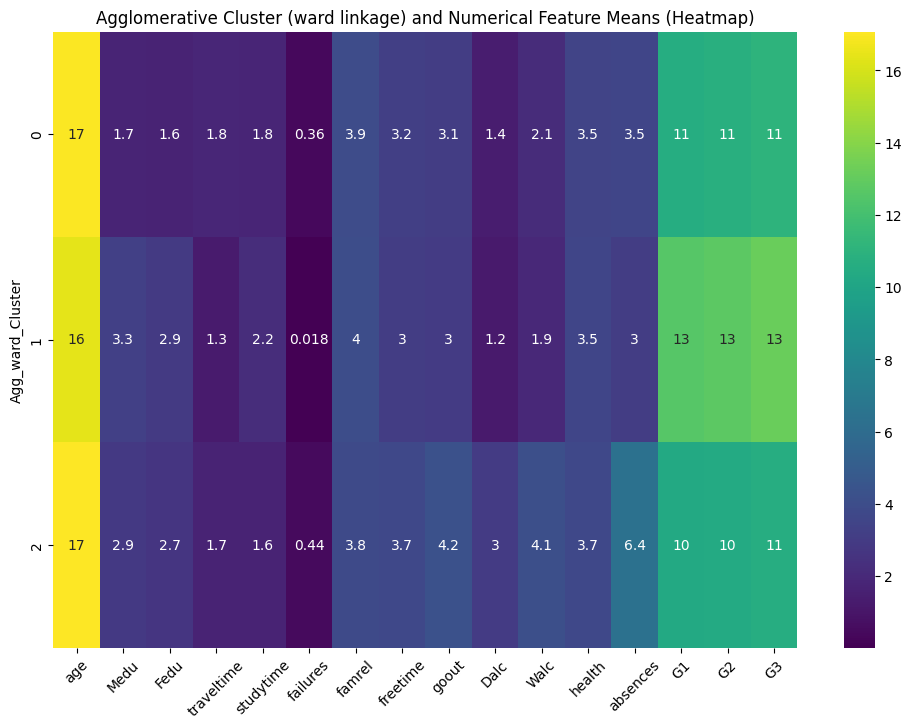

In [21]:
# creating a heatmap to analyze the clusters vis-a-vis the numerical columns
agg_ward_cluster_means = studentperf_df.groupby('Agg_ward_Cluster')[numerical_cols].mean()
plt.figure(figsize=(12, 8))
sns.heatmap(agg_ward_cluster_means, annot=True, cmap='viridis')
plt.title('Agglomerative Cluster (ward linkage) and Numerical Feature Means (Heatmap)')
plt.xticks(rotation=45)
plt.show()

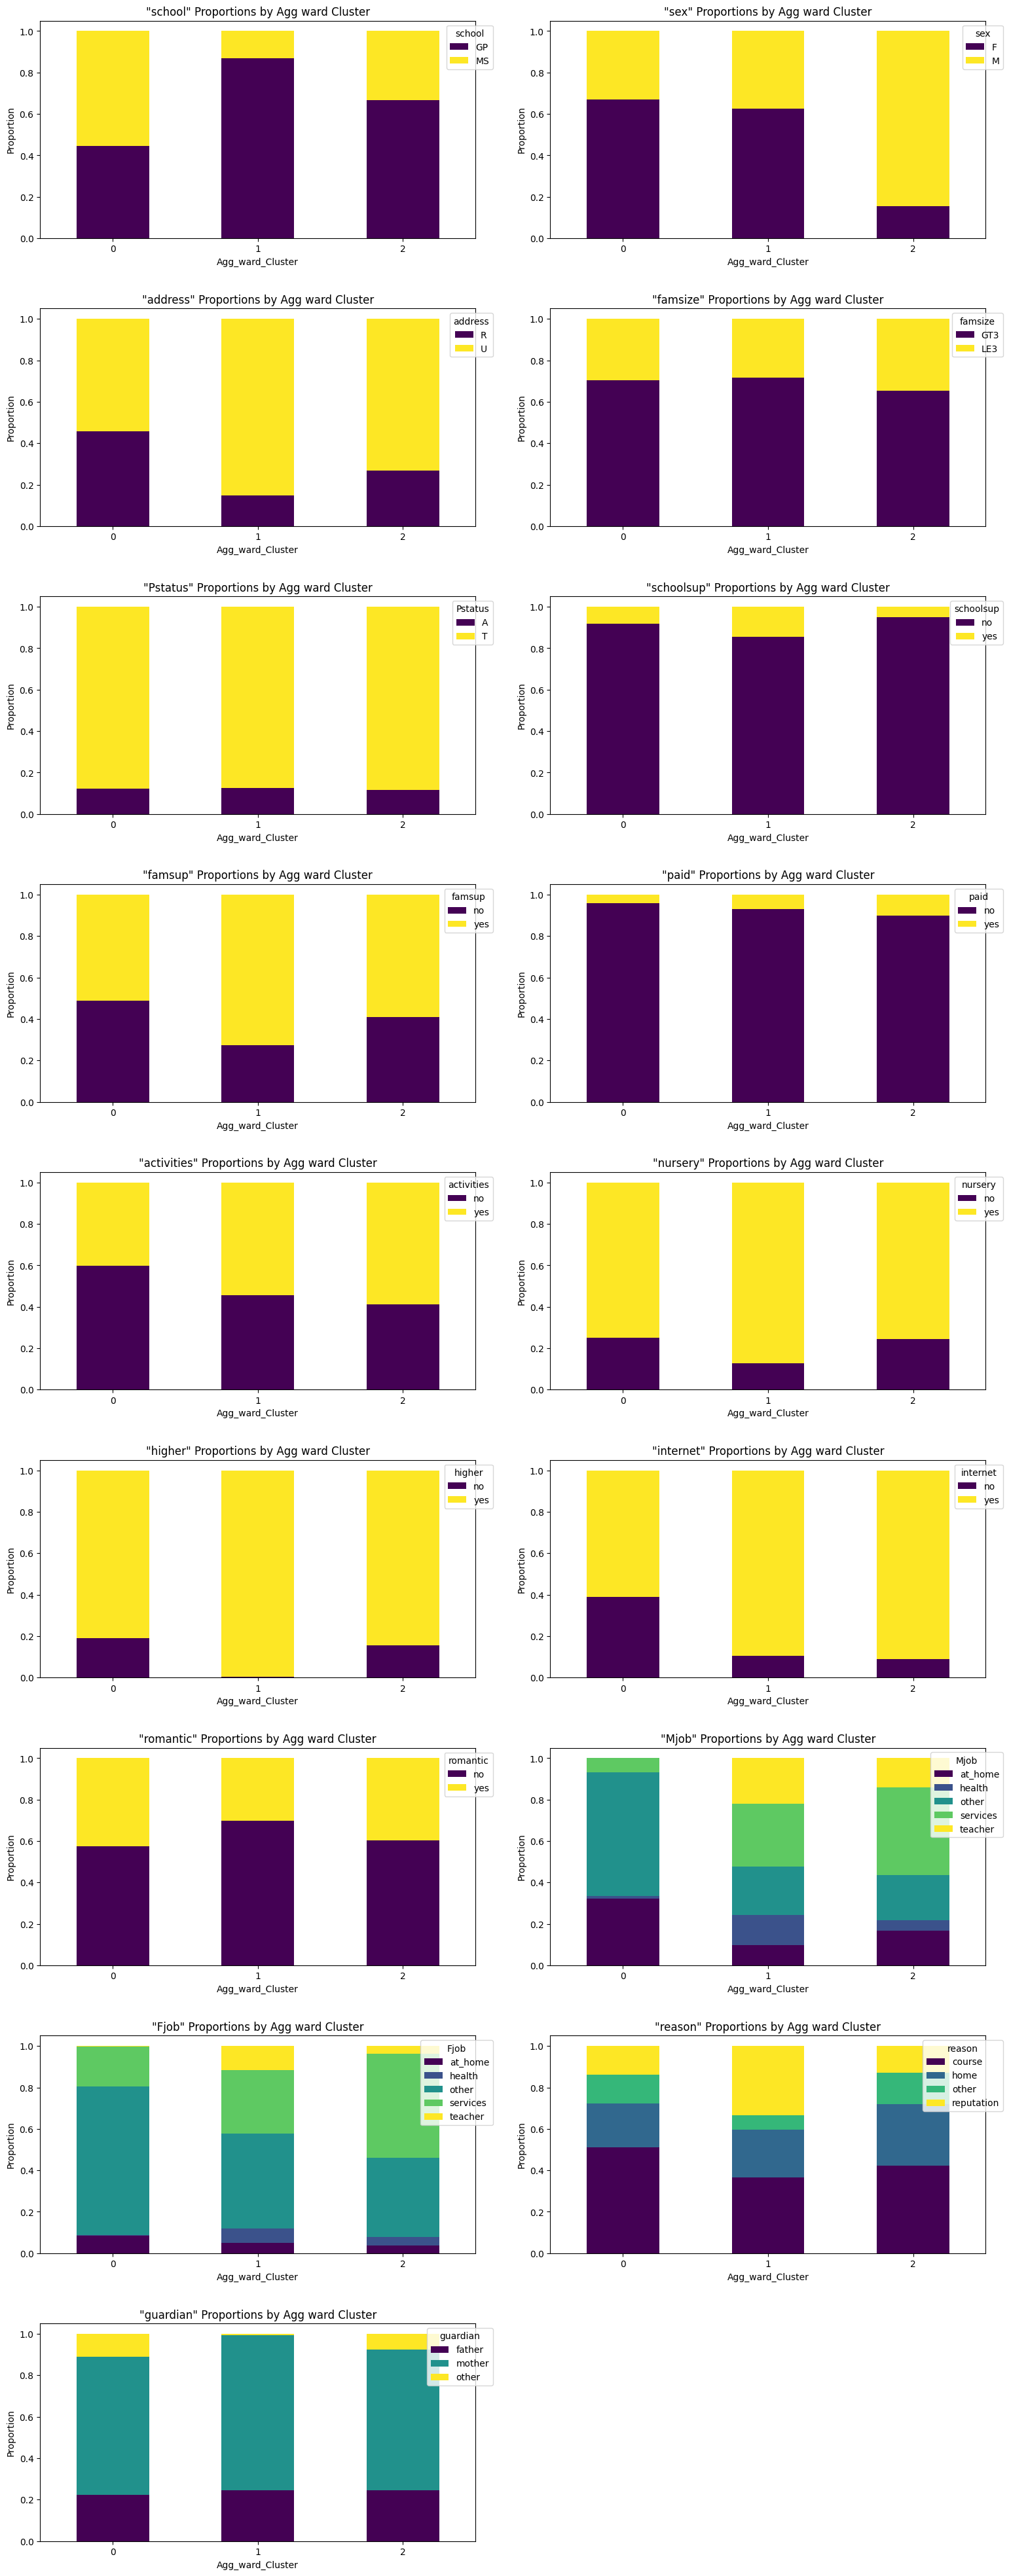

In [22]:
# selecting only the Agg ward Cluster Column
cluster_col = 'Agg_ward_Cluster'

# creating subplots of stacked bar plots
n_rows = 9
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 40))
axes = axes.flatten()

# iterating through all categorical columns
for i, cat_col in enumerate(original_categorical_cols):
    cluster_cat = pd.crosstab(studentperf_df[cluster_col], studentperf_df[cat_col]) # creating crosstab
    cluster_cat.div(cluster_cat.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=axes[i], legend=True, cmap="viridis") # creating stacked bar plot

    # fixing the settings of each plot
    axes[i].set_title(f'"{cat_col}" Proportions by Agg ward Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper right')

# removing any unused subplots
if len(original_categorical_cols) < n_rows * n_cols:
    for j in range(len(original_categorical_cols), n_rows * n_cols):
        fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5)
plt.tight_layout(pad=3.0)
plt.show()

Agglomerative Clustering (using complete linkage) Analysis:

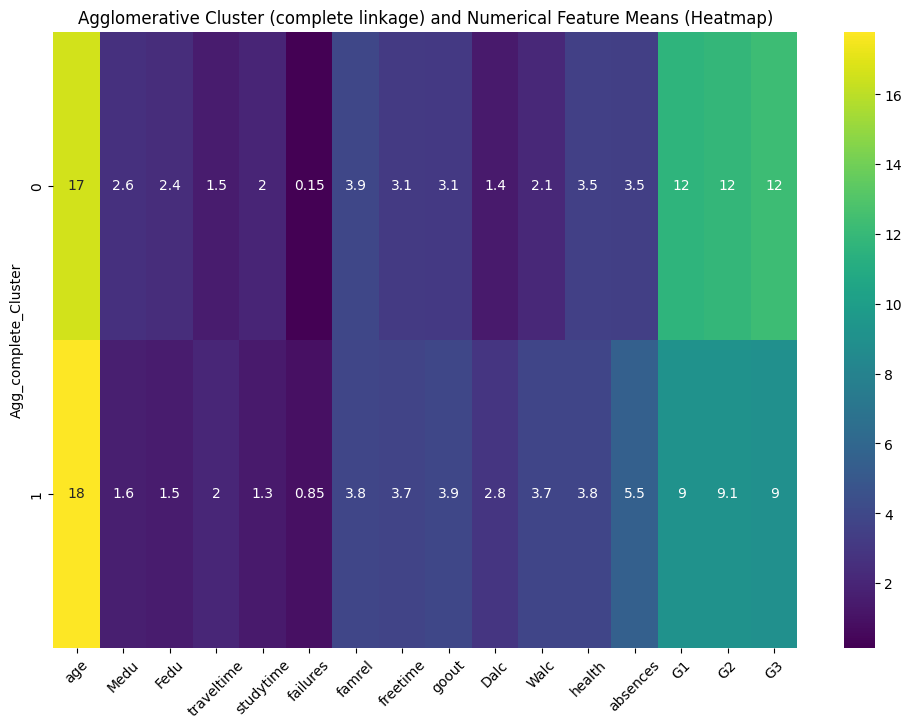

In [23]:
# creating a heatmap to analyze the clusters vis-a-vis the numerical columns
agg_complete_cluster_means = studentperf_df.groupby('Agg_complete_Cluster')[numerical_cols].mean()
plt.figure(figsize=(12, 8))
sns.heatmap(agg_complete_cluster_means, annot=True, cmap='viridis')
plt.title('Agglomerative Cluster (complete linkage) and Numerical Feature Means (Heatmap)')
plt.xticks(rotation=45)
plt.show()

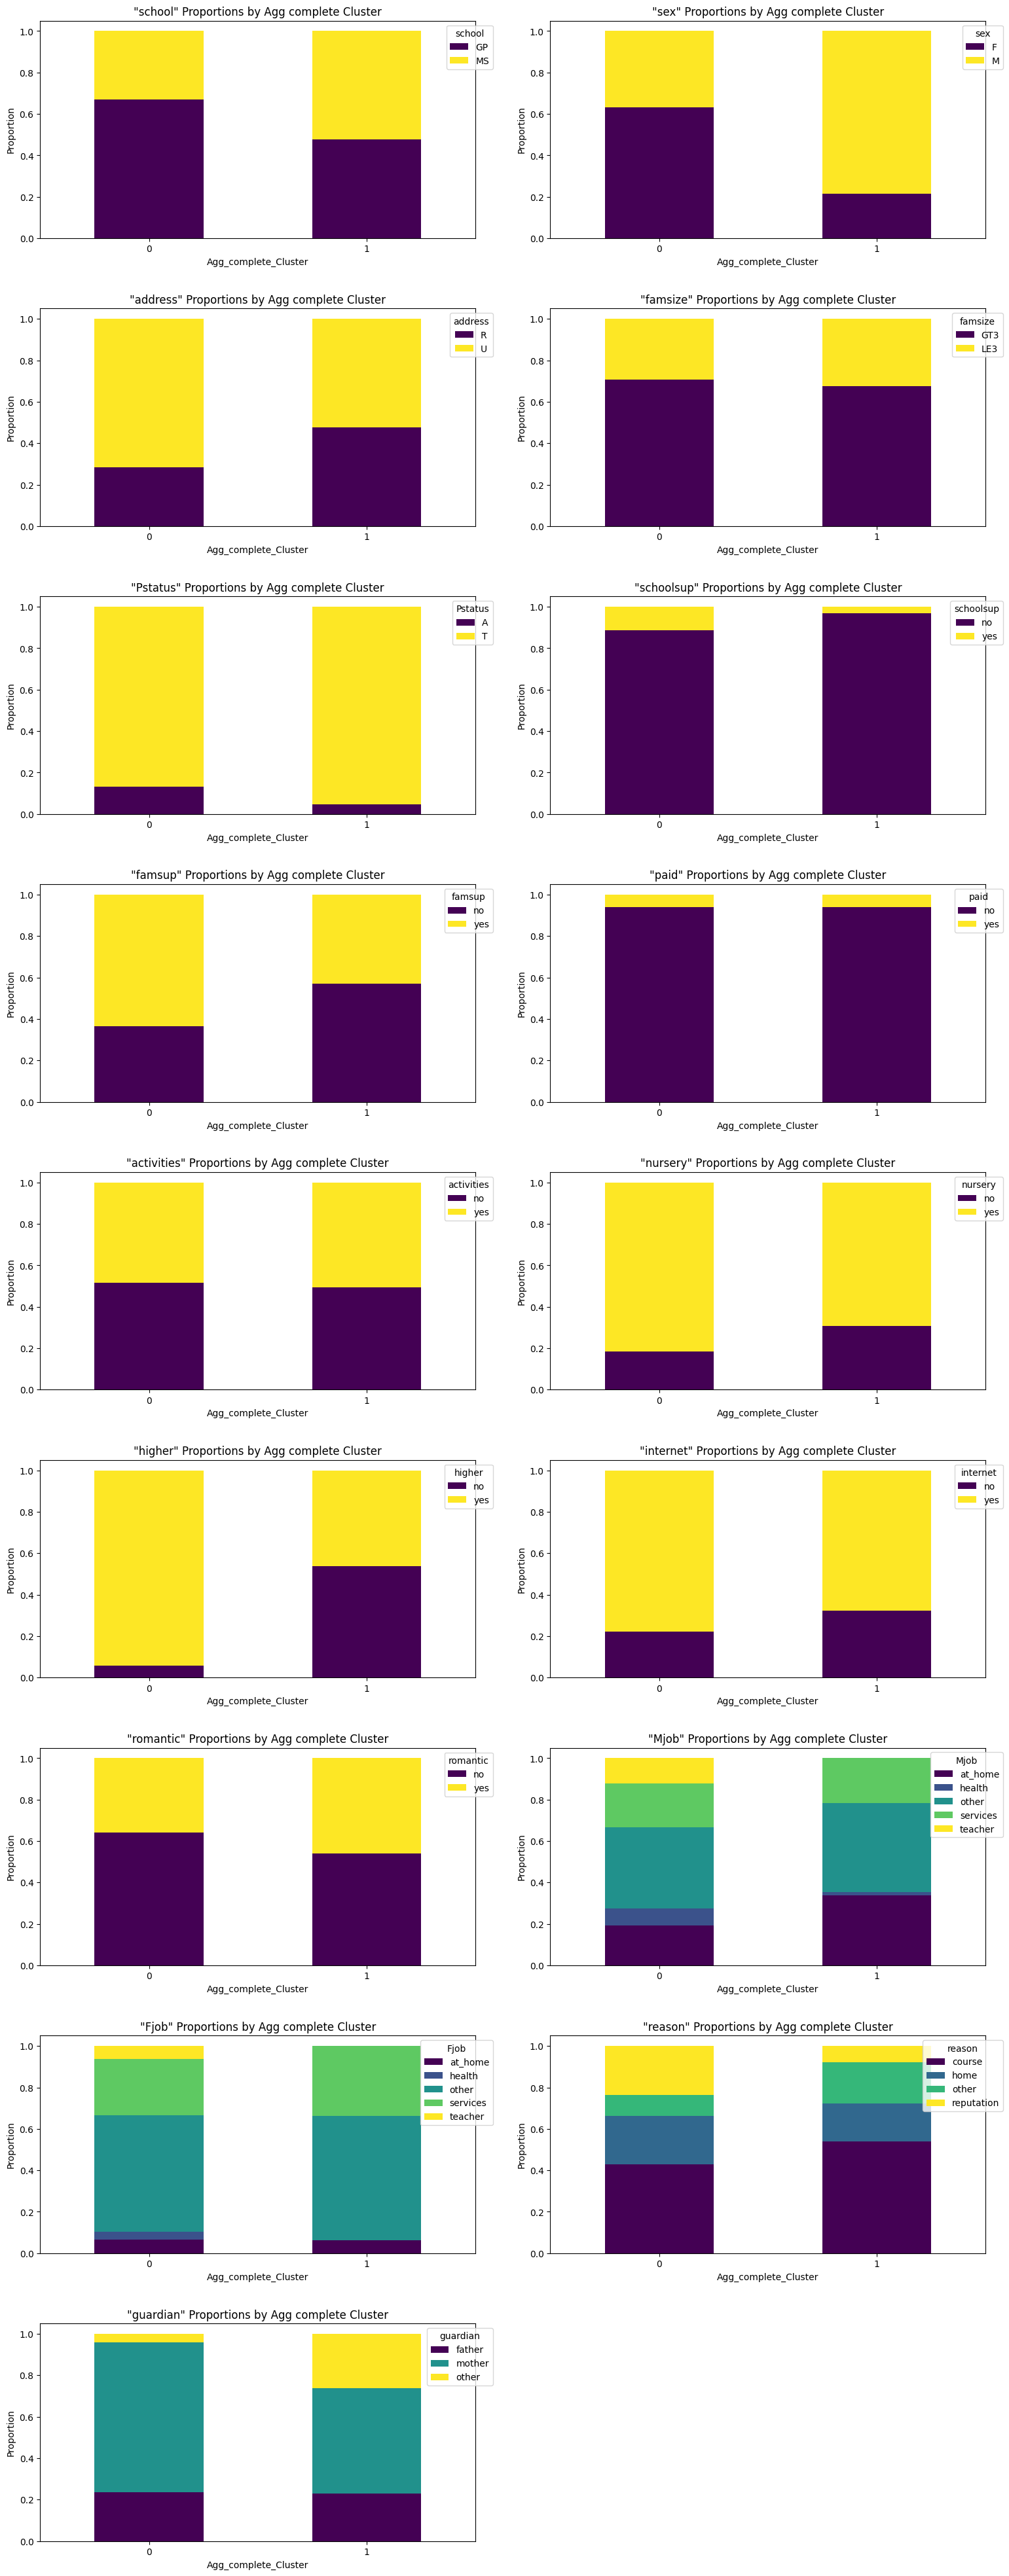

In [24]:
# selecting only the Agg complete Cluster Column
cluster_col = 'Agg_complete_Cluster'

# creating subplots of stacked bar plots
n_rows = 9
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 40))
axes = axes.flatten()

# iterating through all categorical columns
for i, cat_col in enumerate(original_categorical_cols):
    cluster_cat = pd.crosstab(studentperf_df[cluster_col], studentperf_df[cat_col]) # creating crosstab
    cluster_cat.div(cluster_cat.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=axes[i], legend=True, cmap="viridis") # creating stacked bar plot

    # fixing the settings of each plot
    axes[i].set_title(f'"{cat_col}" Proportions by Agg complete Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper right')

# removing any unused subplots
if len(original_categorical_cols) < n_rows * n_cols:
    for j in range(len(original_categorical_cols), n_rows * n_cols):
        fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5)
plt.tight_layout(pad=3.0)
plt.show()

GMM Clustering Analysis:

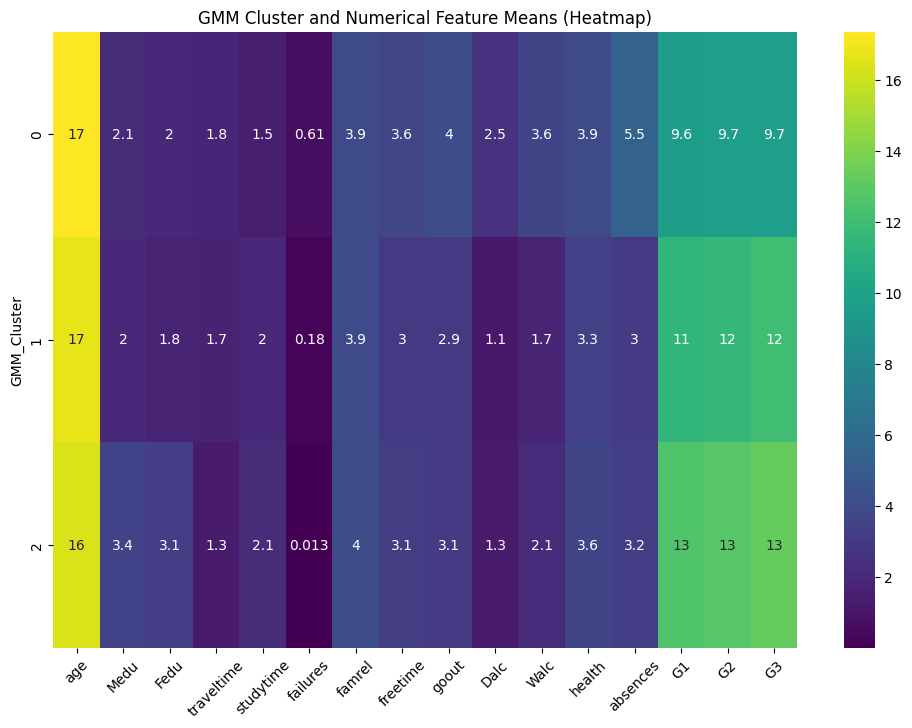

In [25]:
# creating a heatmap to analyze the clusters vis-a-vis the numerical columns
gmm_cluster_means = studentperf_df.groupby('GMM_Cluster')[numerical_cols].mean()
plt.figure(figsize=(12, 8))
sns.heatmap(gmm_cluster_means, annot=True, cmap='viridis')
plt.title('GMM Cluster and Numerical Feature Means (Heatmap)')
plt.xticks(rotation=45)
plt.show()

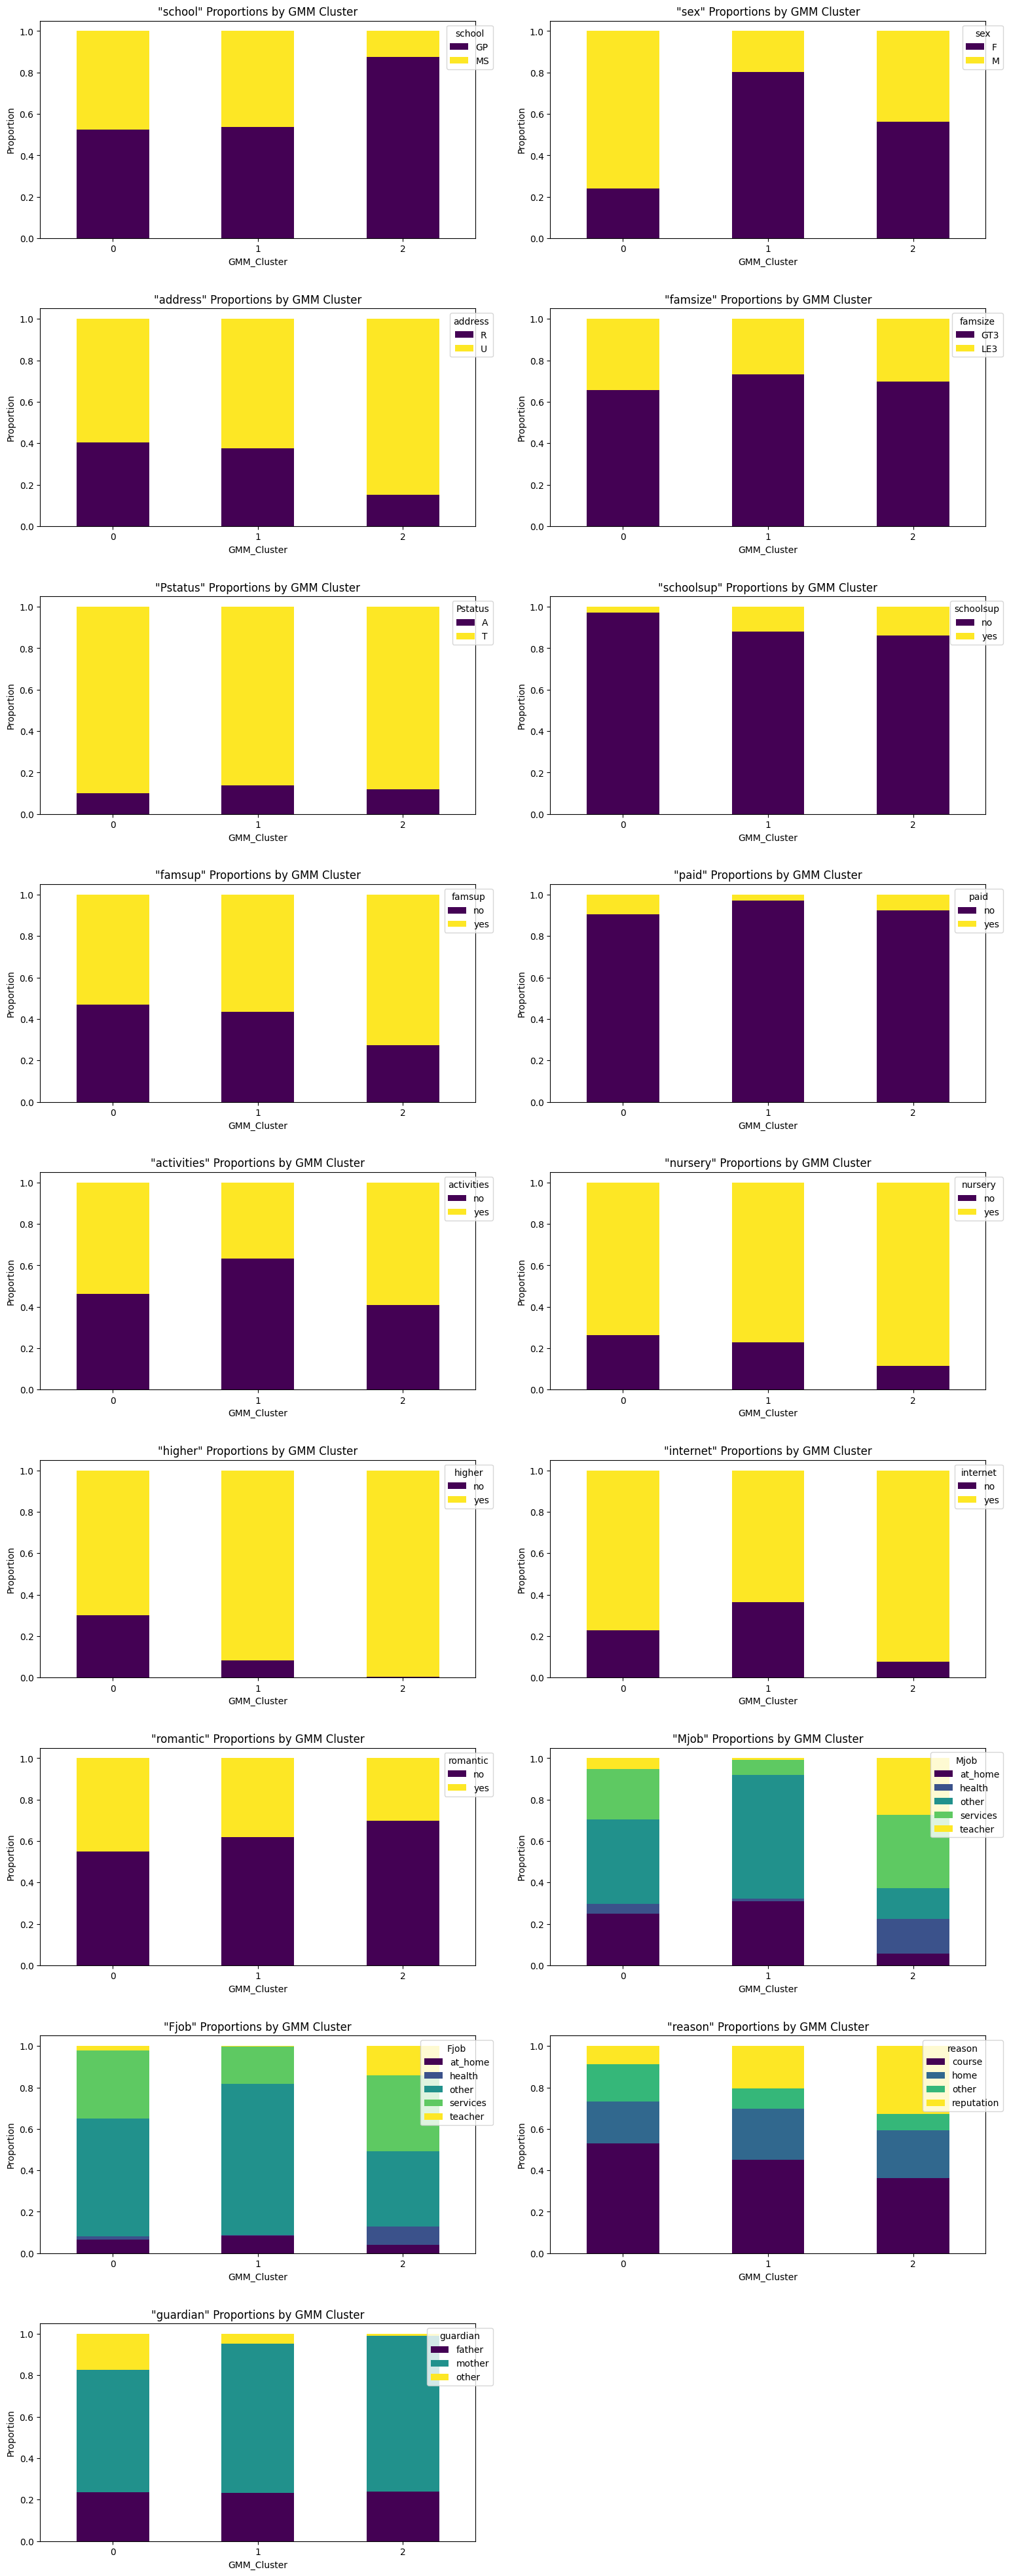

In [26]:
# selecting only the Agg complete Cluster Column
cluster_col = 'GMM_Cluster'

# creating subplots of stacked bar plots
n_rows = 9
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 40))
axes = axes.flatten()

# iterating through all categorical columns
for i, cat_col in enumerate(original_categorical_cols):
    cluster_cat = pd.crosstab(studentperf_df[cluster_col], studentperf_df[cat_col]) # creating crosstab
    cluster_cat.div(cluster_cat.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=axes[i], legend=True, cmap="viridis") # creating stacked bar plot

    # fixing the settings of each plot
    axes[i].set_title(f'"{cat_col}" Proportions by GMM Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper right')

# removing any unused subplots
if len(original_categorical_cols) < n_rows * n_cols:
    for j in range(len(original_categorical_cols), n_rows * n_cols):
        fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5)
plt.tight_layout(pad=3.0)
plt.show()

Spectral Clustering Analysis:

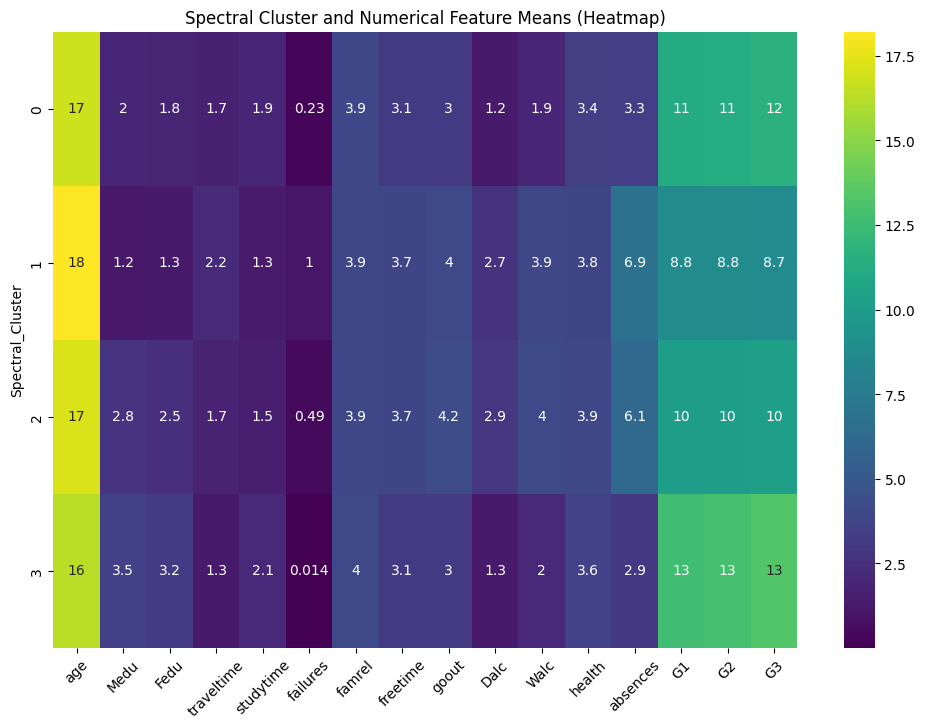

In [27]:
# creating a heatmap to analyze the clusters vis-a-vis the numerical columns
spectral_cluster_means = studentperf_df.groupby('Spectral_Cluster')[numerical_cols].mean()
plt.figure(figsize=(12, 8))
sns.heatmap(spectral_cluster_means, annot=True, cmap='viridis')
plt.title('Spectral Cluster and Numerical Feature Means (Heatmap)')
plt.xticks(rotation=45)
plt.show()

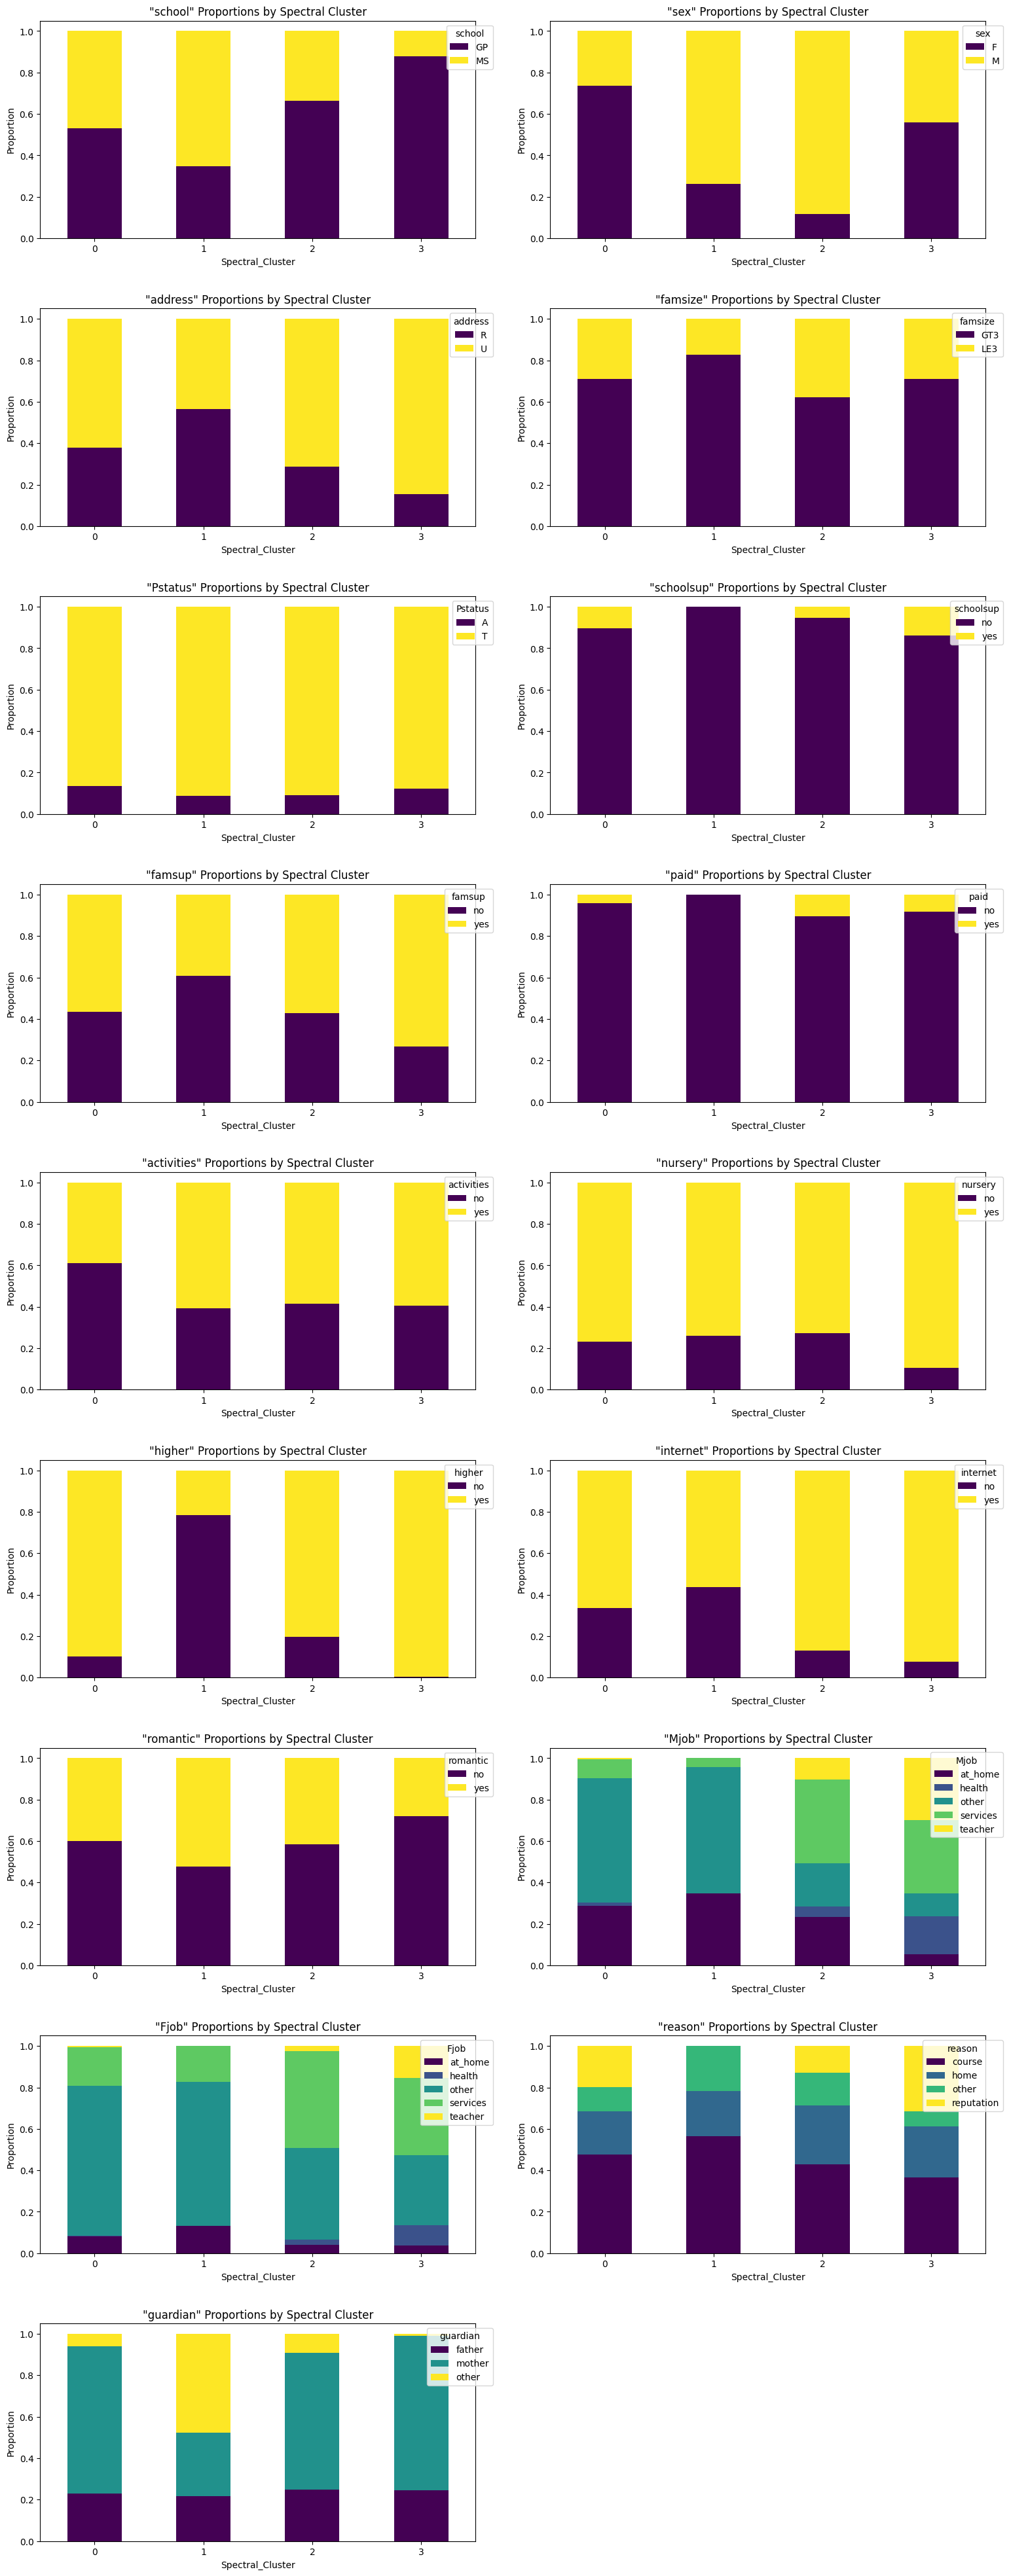

In [28]:
# selecting only the Agg complete Cluster Column
cluster_col = 'Spectral_Cluster'

# creating subplots of stacked bar plots
n_rows = 9
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 40))
axes = axes.flatten()

# iterating through all categorical columns
for i, cat_col in enumerate(original_categorical_cols):
    cluster_cat = pd.crosstab(studentperf_df[cluster_col], studentperf_df[cat_col]) # creating crosstab
    cluster_cat.div(cluster_cat.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=axes[i], legend=True, cmap="viridis") # creating stacked bar plot

    # fixing the settings of each plot
    axes[i].set_title(f'"{cat_col}" Proportions by Spectral Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper right')

# removing any unused subplots
if len(original_categorical_cols) < n_rows * n_cols:
    for j in range(len(original_categorical_cols), n_rows * n_cols):
        fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5)
plt.tight_layout(pad=3.0)
plt.show()

Based on the heatmaps and count plots, "student profiles" can be created from the clusters formed. Upon inspection, the following profiles follow the general trend narrated below. However, it must be noted in some clustering methods, two and four clusters are formed so the profiles indicated below are not necessarily accurate. Even so, the general trend are still captured by the profiles. As an example, the following are the specific profiles formed by analyzing the results from K-Means Clustering: 

**Cluster 0:**
* Students are more tired (has the most travel time to school and the least amount of study time, compared to the other two clusters)
* Goes out with friends the most
* Consumes alcohol the most but surprisingly, has the highest health status
* Has the most number of class absences compared to the other two clusters
* Students have the lowest grades compared to Clusters 1 and 2
* Majority are from Mousinho da Silveira
* An overwhelming ajority are male
* Has the highest proportion of students living outside the city (rural) compared to the other two clusters
* Has the highest proportion of students without extra educational support, compared to the other two clusters
* Has the least proportion of students with family educational support, compared to the other two clusters
* Proportion of students engaged in extra-curricular activities almost equals that of Cluster 2
* Majority attended nursery school, but in the least proportion than those in Clusters 1 and 2
* Majority wants to pursue higher education, but in the least proportion than those in Clusters 1 and 2
* Has more internet access at home than those in Cluster 1
* Has more students engaged in romantic relationships 
* Has the highest proportion of students choosing "course" as the reason for choosing the school
* Has the highest proportion of students with "other" as the primary guardian, compared to the other two clusters


**Cluster 1:**
* Parents are the least educated (although relatively similar to those in Cluster 0)
* Travel time is in between those of Cluster 0 and Cluster 2
* Has more study time than Cluster 0 but less than Cluster 2
* Has more class failures than Cluster 2 but less than Cluster 0
* Has the least amount of free time
* Goes out with friends the least compared to the two other clusters
* Consumes the least amount of alcohol
* Current health status is least compared to the two other clusters but still health (middle of 1 - very bad - and 5 - very good)
* Has the least number of school absences
* Grades are close to those in Cluster 2 and definitely higher than those in Cluster 0
* Balanced number of students from Gabriel Pereira and Mousinho de Silveira
* Majority are female
* More students live in the city (urban) compared to those in Cluster 0, but less proportion than those in Cluster 2
* Has more family educational support than those in Cluster 0, but less than those in Cluster 2
* Has the least amount of students engaged in extra-curricular activities
* Students attended nursery school, relatively more than those in Cluster 0
* Majority wanted to pursue higher education, more than those in Cluster 0
* Has the least proportion of students having internet access at home, compared to the two other clusters
* Has less students in romantic relationships, compared to Cluster 0
* Majority of the parents' jobs fall in the "other" category
* Majority has mother as their primary guardian 

**Cluster 2:**
* Parents are more educated (some are teachers)
* Less travel time to school
* Relatively have the most study time
* Has definitely less class failures
* Goes out with friends more than those in Cluster 1
* Consumes relatively more alcohol than those in Cluster 1
* Has a relatively higher health status than those in Cluster 1
* Has a relatively higher number of absences than those in Cluster 1
* Has the highest grades
* Majority belongs to Gabriel Pereira school
* Balanced male and female students
* Majority lives in the city (urban)
* Has the most family educational support
* Has the greatest proportion of students engagaed in extra-curricular activities
* Most attended nursery school
* Overwhelming majority wants to take higher education
* Most have internet access at home
* Has the least amount of romantic relationships than the other clusters
* Has the highest proportion of students choosing the "reputation" of the school as their reason for choosing the school
* Has the highest proportion of mother as their primary guardian

Note: Interesting results from GMM and Spectral Clustering (which created two and four clusters, respectively) warrant a further, closer analysis which is envisioned to be included in an updated version of this notebook. 

## Summary

* Student performance clustering has been done using the Student Performance Dataset.
* EDA has been performed on the dataset. Afterwards, data has been transformed so that it is suitable for clustering.
* Due to the tremendous amount of features, 2D PCA has been conducted. This PCA-transformed data has been primarily used for clustering. 
* Different methods are tested for clustering: from K-Means Clustering up to Spectral Clustering. To evaluate the clusters formed, silhouette scores are obtained and the clusters are plotted (along with the PCA-transformed data).
* Based on the silhouette scores, all methods used resulted in a "weak structure" of clusters (0.35 to about 0.60 silhouette scores).
* In order to analyze the results after clustering, the assigned clusters (based on a specific method) are appended to the original DataFrame. This allows for the creation of student profiles based on the formed clusters. 
* For the creation of the profiles, only the clusters formed from selected methods are considered since some clusters formed in other methods are trivial (such as only two clusters - one big chunk of points as one cluster and the outliers as the other). 